## Import Library

In [1]:

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time
import json, pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.utils import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (
    Embedding, LSTM, GRU, Dense, Dropout,
    Bidirectional, GlobalMaxPool1D, Conv1D,
    MaxPooling1D, BatchNormalization, Flatten, GlobalAveragePooling1D,
)
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.layers import Layer
import datetime
from collections import Counter


from transformers import BertTokenizer, TFBertModel

print(f"✓ TensorFlow  : {tf.__version__}")
print(f"✓ Transformers: {__import__('transformers').__version__}")


✓ TensorFlow  : 2.15.0
✓ Transformers: 4.38.2


In [2]:
# Inisiasi variabel Global
RANDOM_SEED   = 42
NUM_WORDS     = 10000
MAX_LENGTH    = 200
EMBED_DIM     = 128
EPOCH         = 50
BATCH_SIZE    = 32
OUTPUT_DIR    = './results'
ARTIFACTS_DIR  = './results/artifacts'
LOGS_DIR      = './results/logs'
ALL_MODELS_DIR  = './results/all_models'
BEST_MODEL_DIR   = './results/best_model'
DATASET_PATH   = 'D:\\Farizky\\casptoneAfterCrash\\healmate_ai\\AI\\eksperimen2\\farizky\\Emotion Dataset Merged.xlsx'  

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
#tes

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)
os.makedirs(ALL_MODELS_DIR, exist_ok=True)
os.makedirs(BEST_MODEL_DIR, exist_ok=True)
LOG_DIR = os.path.join(LOGS_DIR, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

## Load Dataset

In [3]:
df =pd.read_excel(DATASET_PATH)
print(f'Shape : {df.shape}')
df.head()

Shape : (6403, 7)


,input_clean,input_no_punct,anger_prob,anxiety_prob,acceptance_prob,predicted_emotion,emotion_confidence
0,i am feeling unloved and unwanted and as if th...,i am feeling unloved and unwanted and as if th...,0.211942,0.211942,0.576117,acceptance,0.576117
1,i am fighting with my mind trying to tell myse...,i am fighting with my mind trying to tell myse...,0.106507,0.786986,0.106507,anxiety,0.786986
2,i felt i won an argument afterwards i felt mys...,i felt i won an argument afterwards i felt mys...,0.211942,0.211942,0.576117,acceptance,0.576117
3,i felt as if i was fighting a battle that i wa...,i felt as if i was fighting a battle that i wa...,0.045279,0.045279,0.909443,acceptance,0.909443
4,i miss you i miss the chats but it is the any ...,i miss you i miss the chats but it is the any ...,0.114195,0.843795,0.042010,anxiety,0.843795


## EDA

In [4]:
df.info()
print('\nMissing values:')
print(df.isnull().sum())
print(f'\nDuplikat : {df.duplicated().sum()}')
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6403 entries, 0 to 6402
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   input_clean         6403 non-null   str    
 1   input_no_punct      6403 non-null   str    
 2   anger_prob          6403 non-null   float64
 3   anxiety_prob        6403 non-null   float64
 4   acceptance_prob     6403 non-null   float64
 5   predicted_emotion   6403 non-null   str    
 6   emotion_confidence  6403 non-null   float64
dtypes: float64(4), str(3)
memory usage: 350.3 KB

Missing values:
input_clean           0
input_no_punct        0
anger_prob            0
anxiety_prob          0
acceptance_prob       0
predicted_emotion     0
emotion_confidence    0
dtype: int64

Duplikat : 0


,anger_prob,anxiety_prob,acceptance_prob,emotion_confidence
count,6403.000000,6403.000000,6403.000000,6403.000000
mean,0.408670,0.337699,0.253632,0.656738
std,0.276955,0.261953,0.207724,0.165127
min,0.000017,0.000017,0.000017,0.344535
25%,0.211942,0.194653,0.106507,0.576117
50%,0.327732,0.211942,0.211942,0.576117
75%,0.576117,0.576117,0.327732,0.786986
max,0.999967,0.999967,0.998180,0.999967


In [5]:

#Distribusi panjang teks
df['input_length'] = df['input_clean'].str.split().str.len()
df['label_length'] = df['predicted_emotion'].str.split().str.len()
print(df[['input_length', 'label_length']].describe())

#Cek duplikat input (input sama, label berbeda)
print(f"Input unik: {df['input_clean'].nunique()} dari {len(df)} total")

#Cek label noise (confidence rendah)
print(df[df['emotion_confidence'] < 0.5]['predicted_emotion'].value_counts())


       input_length  label_length
count   6403.000000        6403.0
mean      23.524442           1.0
std       13.317964           0.0
min        2.000000           1.0
25%       14.000000           1.0
50%       21.000000           1.0
75%       31.000000           1.0
max      158.000000           1.0
Input unik: 6403 dari 6403 total
predicted_emotion
anxiety       408
anger         254
acceptance     34
Name: count, dtype: int64


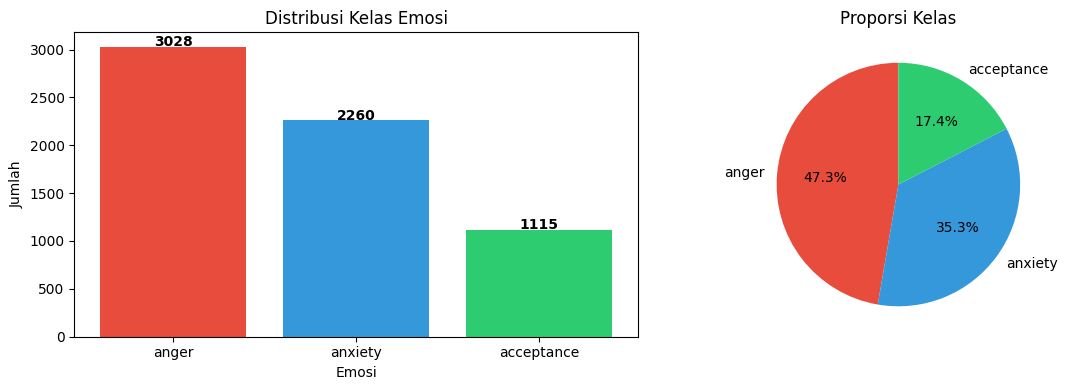

predicted_emotion
anger         3028
anxiety       2260
acceptance    1115
Name: count, dtype: int64


In [6]:
 # ── Distribusi Kelas ─────────────────────────────────────────
label_counts = df['predicted_emotion'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(label_counts.index, label_counts.values,
            color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('Distribusi Kelas Emosi')
axes[0].set_xlabel('Emosi')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=['#e74c3c', '#3498db', '#2ecc71'],
            startangle=90)
axes[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.show()
print(label_counts)

## Split Data

In [7]:

df['healing_score'] = df['acceptance_prob'] - (df['anger_prob'] + df['anxiety_prob']) / 2

df.sample(10)

,input_clean,input_no_punct,anger_prob,anxiety_prob,acceptance_prob,predicted_emotion,emotion_confidence,input_length,label_length,healing_score
3482,i thought that all those thing we dealt with o...,i thought that all those thing we dealt with o...,0.593772,0.080358,0.325869,anger,0.593772,49,1,-0.011196
1905,unwanted feel unloved and i,unwanted feel unloved and i,0.106507,0.786986,0.106507,anxiety,0.786986,5,1,-0.340240
4291,miss having a boyfriend this lonely shit not t...,miss having a boyfriend this lonely shit not t...,0.044435,0.892508,0.063057,anxiety,0.892508,10,1,-0.405415
1330,i am crushed i must say in passing but i feel ...,i am crushed i must say in passing but i feel ...,0.474226,0.174458,0.351316,anger,0.474226,47,1,0.026973
4989,many storms life cheated hurt feeling like dre...,many storms life cheated hurt feeling like dre...,0.892508,0.044435,0.063057,anger,0.892508,19,1,-0.405415
6271,i often think back to when my husband and i fi...,i often think back to when my husband and i fi...,0.327732,0.344535,0.327732,anxiety,0.344535,13,1,-0.008402
1941,i dissociated and get fatigued because i am co...,i dissociated and get fatigued because i am co...,0.211942,0.211942,0.576117,acceptance,0.576117,20,1,0.364175
764,i encouraged an older guy to talk to his partn...,i encouraged an older guy to talk to his partn...,0.106507,0.786986,0.106507,anxiety,0.786986,37,1,-0.340240
2045,i feel a you have some fucked up definition of...,i feel a you have some fucked up definition of...,0.529121,0.194653,0.276226,anger,0.529121,46,1,-0.085662
2272,i was heartbroken and so confused and feeling ...,i was heartbroken and so confused and feeling ...,0.529121,0.194653,0.276226,anger,0.529121,24,1,-0.085662


In [8]:
X = df['input_clean'].fillna('').astype(str)
y = df['predicted_emotion']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

NUM_CLASSES = len(le.classes_)

print('\nLabel encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls:12s} → {i}')

y_healing = df['healing_score'].values.astype(np.float32)
print(f'\nHealing score — min: {y_healing.min():.4f}, max: {y_healing.max():.4f}, mean: {y_healing.mean():.4f}')

with open(os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)
print("✓ Label encoder disimpan.")


Label encoding:
  acceptance   → 0
  anger        → 1
  anxiety      → 2

Healing score — min: -0.5000, max: 0.9973, mean: -0.1196
✓ Label encoder disimpan.


In [9]:
X_train, X_temp, y_train, y_temp, yh_train, yh_temp = train_test_split(
    X, y_encoded, y_healing,
    test_size=0.2, random_state=RANDOM_SEED, stratify=y_encoded
)

X_val, X_test, y_val, y_test, yh_val, yh_test = train_test_split(
    X_temp, y_temp, yh_temp,
    test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
)

print(f'\nData split:')
print(f'  Train set : {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Val set   : {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test set  : {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)')

print("Distribusi train:", Counter(y_train))
print("Distribusi val:  ", Counter(y_val))
print("Distribusi test: ", Counter(y_test))



Data split:
  Train set : 5,122 samples (80.0%)
  Val set   : 640 samples (10.0%)
  Test set  : 641 samples (10.0%)
Distribusi train: Counter({1: 2422, 2: 1808, 0: 892})
Distribusi val:   Counter({1: 303, 2: 226, 0: 111})
Distribusi test:  Counter({1: 303, 2: 226, 0: 112})


## Tokenisasi dan Padding

In [10]:
tokenizer = Tokenizer(num_words=NUM_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

vocab_size = NUM_WORDS + 1

print(f'Kamus aktual tokenizer : {len(tokenizer.word_index):,} kata unik')
print(f'Kata yang dipakai model: {NUM_WORDS:,} (num_words)')
print(f'vocab_size (embedding) : {vocab_size:,}  ← index 0..{NUM_WORDS}')

sample_seq = tokenizer.texts_to_sequences([X_train.iloc[0]])
max_idx = max(sample_seq[0]) if sample_seq[0] else 0
print(f'\nCek sample — max index dari 1 kalimat: {max_idx} (harus ≤ {NUM_WORDS})')

def texts_to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LENGTH, padding='post', truncating='post')

X_train_seq = texts_to_padded(X_train)
X_val_seq   = texts_to_padded(X_val)
X_test_seq  = texts_to_padded(X_test)

print(f'\nShape setelah padding:')
print(f'  Train : {X_train_seq.shape}')
print(f'  Val   : {X_val_seq.shape}')
print(f'  Test  : {X_test_seq.shape}')

all_max = X_train_seq.max()
print(f'\nMax token index di X_train_seq : {all_max} (harus ≤ {NUM_WORDS})')
if all_max > NUM_WORDS:
    print(f' WARNING: Ada index {all_max} melebihi NUM_WORDS {NUM_WORDS}!')
else:
    print(f' Semua index aman, embedding matrix [{vocab_size} baris] cukup.')

with open(os.path.join(ARTIFACTS_DIR, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)
print('\n Tokenizer disimpan.')

Kamus aktual tokenizer : 6,402 kata unik
Kata yang dipakai model: 10,000 (num_words)
vocab_size (embedding) : 10,001  ← index 0..10000

Cek sample — max index dari 1 kalimat: 1158 (harus ≤ 10000)

Shape setelah padding:
  Train : (5122, 200)
  Val   : (640, 200)
  Test  : (641, 200)

Max token index di X_train_seq : 6402 (harus ≤ 10000)
 Semua index aman, embedding matrix [10001 baris] cukup.

 Tokenizer disimpan.


### Pembuatan Tf.data.dataset

In [11]:
train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train_seq, (y_train, yh_train)))
    .shuffle(len(X_train_seq), seed=RANDOM_SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val_seq, (y_val, yh_val)))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test_seq, (y_test, yh_test)))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight = {i: w for i, w in enumerate(class_weights_arr)}

print(f"  train_ds : {len(list(train_ds))} batch")
print(f"  val_ds   : {len(list(val_ds))} batch")
print(f"  test_ds  : {len(list(test_ds))} batch")
print(f"\nClass weight: {class_weight}")

  train_ds : 161 batch
  val_ds   : 20 batch
  test_ds  : 21 batch

Class weight: {0: 1.914050822122571, 1: 0.7049270575282136, 2: 0.9443215339233039}


## Modeling

### Custom Layer

In [12]:
class CustomEmbeddingLayer(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.embed_dim  = embed_dim

    def build(self, input_shape):
        self.embedding_matrix = self.add_weight(
            name='embedding_matrix',
            shape=(self.vocab_size, self.embed_dim),
            initializer=tf.keras.initializers.TruncatedNormal(stddev=0.02),
            trainable=True
        )
        super().build(input_shape)

    def call(self, token_ids):
        x    = tf.nn.embedding_lookup(self.embedding_matrix, token_ids)
        mask = tf.cast(tf.not_equal(token_ids, 0), tf.float32)
        mask = tf.expand_dims(mask, -1)
        return x * mask

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'vocab_size': self.vocab_size, 'embed_dim': self.embed_dim})
        return cfg


class CustomDenseLayer(tf.keras.layers.Layer):
    def __init__(self, units=32, activation='relu', dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.units        = units
        self.activation   = tf.keras.activations.get(activation)
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        self.W = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        self.dropout = tf.keras.layers.Dropout(self.dropout_rate)
        super().build(input_shape)

    def call(self, inputs, training=None):
        x = tf.matmul(inputs, self.W) + self.b
        x = self.activation(x)
        x = self.dropout(x, training=training)
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'units': self.units,
            'dropout_rate': self.dropout_rate,
            'activation': tf.keras.activations.serialize(self.activation),
        })
        return cfg


class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.W_query = self.add_weight(
            name='W_query',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform', trainable=True
        )
        self.W_key = self.add_weight(
            name='W_key',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform', trainable=True
        )
        self.V = self.add_weight(
            name='V',
            shape=(self.units, 1),
            initializer='glorot_uniform', trainable=True
        )
        self.b = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros', trainable=True
        )
        super().build(input_shape)

    def call(self, inputs, mask=None):
        query   = tf.tanh(tf.matmul(inputs, self.W_query) + self.b)
        key     = tf.tanh(tf.matmul(inputs, self.W_key))
        score   = tf.matmul(query + key, self.V)          

      
        if mask is not None:
            mask   = tf.cast(mask, tf.float32)
            mask   = tf.expand_dims(mask, -1)             
            score  = score + (1.0 - mask) * -1e9         

        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(inputs * weights, axis=1)
        return context

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units})
        return cfg


class CustomConv1DLayer(tf.keras.layers.Layer):
    def __init__(self, filters=128, kernel_size=5,
                 activation='relu', dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.filters      = filters
        self.kernel_size  = kernel_size
        self.activation   = tf.keras.activations.get(activation)
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        self.conv = tf.keras.layers.Conv1D(
            filters=self.filters,
            kernel_size=self.kernel_size,
            padding='same',
            use_bias=False
        )
        self.bn      = tf.keras.layers.BatchNormalization()
        self.dropout = tf.keras.layers.Dropout(self.dropout_rate)
        super().build(input_shape)

    def call(self, inputs, training=None):   
        x = self.conv(inputs)
        x = self.bn(x, training=training)
        x = self.activation(x)
        x = self.dropout(x, training=training)
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'filters':      self.filters,
            'kernel_size':  self.kernel_size,
            'dropout_rate': self.dropout_rate,
            'activation':   tf.keras.activations.serialize(self.activation),  # ← tambahkan
        })
        return cfg

### Custom LossFN

In [13]:
class CustomLossFunction(tf.keras.losses.Loss):
    def __init__(self, smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.smoothing = smoothing   

    def call(self, y_true, y_pred):
        num_classes = tf.shape(y_pred)[-1]
        num_classes_f = tf.cast(num_classes, tf.float32)
        
        y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
        
        smooth_labels = y_true_onehot * (1.0 - self.smoothing) + \
                        (self.smoothing / num_classes_f)
        
        y_pred_clipped = tf.clip_by_value(y_pred, 1e-7, 1.0)
        
        loss = -tf.reduce_sum(smooth_labels * tf.math.log(y_pred_clipped), axis=-1)
        return tf.reduce_mean(loss)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'smoothing': self.smoothing})
        return cfg


class MultiOutputLoss(tf.keras.losses.Loss):
    def __init__(self, emotion_weight=0.7, healing_weight=0.3,
                 smoothing=0.1, huber_delta=0.5, **kwargs):  
        super().__init__(**kwargs)
        self.emotion_weight = emotion_weight
        self.healing_weight = healing_weight
        self.smoothing      = smoothing
        self.huber_delta    = huber_delta
        self._emotion_loss  = CustomLossFunction(smoothing=smoothing)  
        self._huber         = tf.keras.losses.Huber(delta=huber_delta)

    def call(self, y_true, y_pred):
        y_emotion,    y_healing    = y_true
        pred_emotion, pred_healing = y_pred

        loss_emotion = self._emotion_loss(y_emotion, pred_emotion)
        loss_healing = self._huber(
            tf.expand_dims(y_healing, -1),
            pred_healing
        )
        return self.emotion_weight * loss_emotion + self.healing_weight * loss_healing

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'emotion_weight': self.emotion_weight,
            'healing_weight': self.healing_weight,
            'smoothing':      self.smoothing,
            'huber_delta':    self.huber_delta,
        })
        return cfg


class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        ce    = tf.keras.losses.sparse_categorical_crossentropy(
            y_true, y_pred, from_logits=False
        )
        pt    = tf.exp(-ce)
        focal = self.alpha * tf.pow(1.0 - pt, self.gamma) * ce
        return tf.reduce_mean(focal)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'alpha': self.alpha})
        return cfg


class LabelSmoothingLoss(tf.keras.losses.Loss):
    def __init__(self, num_classes, smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.smoothing   = smoothing

    def call(self, y_true, y_pred):
        y_true_onehot = tf.one_hot(
            tf.cast(y_true, tf.int32),
            depth=self.num_classes
        )
        smooth_labels = (
            y_true_onehot * (1.0 - self.smoothing) +
            (self.smoothing / self.num_classes)
        )
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        loss   = -tf.reduce_sum(smooth_labels * tf.math.log(y_pred), axis=-1)
        return tf.reduce_mean(loss)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_classes': self.num_classes, 'smoothing': self.smoothing})
        return cfg


### Custom CallBack


In [14]:
class CustomEarlyStopping(tf.keras.callbacks.Callback):
    """Early stopping + otomatis restore bobot terbaik saat berhenti."""
    def __init__(self, patience=5, min_delta=0.001, restore_best_weights=True):
        super().__init__()
        self.patience             = patience
        self.min_delta            = min_delta
        self.restore_best_weights = restore_best_weights
        self.wait                 = 0
        self.best_loss            = np.inf
        self.best_weights         = None  

    def on_train_begin(self, logs=None):
        self.wait         = 0
        self.best_loss    = np.inf
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get('val_loss')
        if current is None:
            return
        if current < self.best_loss - self.min_delta:
            self.best_loss    = current
            self.wait         = 0
            if self.restore_best_weights:
                self.best_weights = self.model.get_weights()  
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"\n[EarlyStopping] Berhenti di epoch {epoch+1} "
                      f"— val_loss tidak membaik selama {self.patience} epoch.")
                if self.restore_best_weights and self.best_weights is not None:
                    self.model.set_weights(self.best_weights)   
                    print(f"[EarlyStopping] ✓ Bobot dikembalikan ke val_loss={self.best_loss:.4f}")
                self.model.stop_training = True


class StopAtAccuracy(tf.keras.callbacks.Callback):
    def __init__(self, target_acc=0.90):
        super().__init__()
        self.target_acc = target_acc

    def on_epoch_end(self, epoch, logs=None):
        # Pantau val_accuracy, bukan train accuracy
        val_acc = logs.get('val_accuracy')
        if val_acc is not None and val_acc >= self.target_acc:
            print(f"\n[StopAtAccuracy] Val accuracy {val_acc:.4f} "
                  f"≥ target {self.target_acc:.2f} di epoch {epoch+1} → stop.")
            self.model.stop_training = True


class CustomModelCheckpoint(tf.keras.callbacks.Callback):

    def __init__(self, filepath, monitor='val_loss', save_best_only=True):
        super().__init__()
        self.filepath       = filepath
        self.monitor        = monitor
        self.save_best_only = save_best_only
        self.best = np.inf if 'loss' in monitor else -np.inf

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None:
            return
        is_better = (
            current < self.best if 'loss' in self.monitor
            else current > self.best
        )
        if not self.save_best_only or is_better:
            print(f"\n[Checkpoint] Simpan model → {self.filepath} "
                  f"({self.monitor}={current:.4f})")
            self.model.save(self.filepath)
            self.best = current


class CustomTensorBoard(tf.keras.callbacks.TensorBoard):

    def __init__(self, log_dir=None, **kwargs):
        log_dir = log_dir or LOG_DIR
        super().__init__(log_dir=log_dir, **kwargs)

    def on_epoch_end(self, epoch, logs=None):
        super().on_epoch_end(epoch, logs)
        if logs:
            print(f"  [TB] Epoch {epoch+1:03d} — "
                  f"loss: {logs.get('loss', 0):.4f}  "
                  f"acc: {logs.get('accuracy', 0):.4f}  "
                  f"val_loss: {logs.get('val_loss', 0):.4f}  "
                  f"val_acc: {logs.get('val_accuracy', 0):.4f}")


class CustomLearningRateScheduler(tf.keras.callbacks.Callback):

    def __init__(self, optimizer, initial_lr=0.001,
                 factor=0.5, patience=3, min_lr=1e-7, min_delta=0.001):
        super().__init__()
        self.optimizer  = optimizer
        self.initial_lr = initial_lr
        self.factor     = factor
        self.patience   = patience
        self.min_lr     = min_lr
        self.min_delta  = min_delta
        self._wait      = 0
        self._best      = np.inf

    def on_train_begin(self, logs=None):
        self._wait = 0
        self._best = np.inf

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get('val_loss', np.inf)
        if val_loss < self._best - self.min_delta:
            self._best = val_loss
            self._wait = 0
        else:
            self._wait += 1
            if self._wait >= self.patience:
                current_lr = float(self.optimizer.learning_rate)
                new_lr     = max(current_lr * self.factor, self.min_lr)
                if new_lr < current_lr:
                    self.optimizer.learning_rate.assign(new_lr)
                    print(f"\n[LRScheduler] val_loss stagnan {self.patience} epoch "
                          f"→ LR {current_lr:.2e} → {new_lr:.2e}")
                self._wait = 0


class TrainingSummaryLogger(tf.keras.callbacks.Callback):

    def __init__(self, save_path=None):
        super().__init__()
        self.save_path  = save_path
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        # pakai getattr agar aman di custom training loop
        params = getattr(self, 'params', None)
        total_batches = params.get('steps', '?') if params else '?'
        print(f"\n[SummaryLogger] Training dimulai — "
              f"{total_batches} batch/epoch\n")

    def on_train_end(self, logs=None):
        elapsed  = time.time() - self.start_time
        avg_loss = logs.get('loss', 'N/A') if logs else 'N/A'
        print(f"\n[SummaryLogger] Selesai dalam {elapsed:.1f} detik")
        print(f"[SummaryLogger] Loss akhir : {avg_loss}")
        if self.save_path:
            self.model.save(self.save_path)
            print(f"[SummaryLogger] Model disimpan → {self.save_path}")


class OverfittingDetector(tf.keras.callbacks.Callback):

    def __init__(self, threshold=0.15):
        super().__init__()
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        train_loss = logs.get('loss', 0)
        val_loss   = logs.get('val_loss', 0)
        gap        = val_loss - train_loss
        if gap > self.threshold:
            print(f"\n[OverfittingDetector] Epoch {epoch+1} — "
                  f"gap={gap:.4f} "
                  f"(train={train_loss:.4f}, val={val_loss:.4f})")



### Custom TrainLOOp

In [15]:
class customTrainingLoop:
    def __init__(
        self,
        model,
        model_name,
        optimizer,
        loss_fn,
        log_dir      = None,
        class_weight = None,
        callbacks    = None,
    ):
        self.model        = model
        self.model_name   = model_name
        self.optimizer    = optimizer
        self.loss_fn      = loss_fn
        self.log_dir      = log_dir or LOG_DIR
        self.class_weight = class_weight
        self.callbacks    = callbacks or []
        self._emotion_loss_fn = CustomLossFunction(smoothing=0.1)

        self.history = {
            'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': [],
            'mae': [], 'val_mae': [],
        }

        self.best_val_loss   = np.inf
        self.checkpoint_path = os.path.join(OUTPUT_DIR, f'{self.model_name}_best.keras')

        self.train_writer = tf.summary.create_file_writer(
            os.path.join(self.log_dir, self.model_name, 'train')
        )
        self.val_writer = tf.summary.create_file_writer(
            os.path.join(self.log_dir, self.model_name, 'val')
        )

        self.train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
        self.train_acc_metric  = tf.keras.metrics.SparseCategoricalAccuracy(name='train_acc')
        self.train_mae_metric  = tf.keras.metrics.MeanAbsoluteError(name='train_mae')
        self.val_loss_metric   = tf.keras.metrics.Mean(name='val_loss')
        self.val_acc_metric    = tf.keras.metrics.SparseCategoricalAccuracy(name='val_acc')
        self.val_mae_metric    = tf.keras.metrics.MeanAbsoluteError(name='val_mae')

        self._huber = tf.keras.losses.Huber(delta=0.5)
        if class_weight is not None:
            self._cw_tensor = tf.constant(list(class_weight.values()), dtype=tf.float32)
        else:
            self._cw_tensor = None


   
    @tf.function
    def _train_step(self, X_batch, y_emotion, y_healing):
       
        if self._cw_tensor is not None:
            sample_weights = tf.gather(self._cw_tensor, tf.cast(y_emotion, tf.int32))
        else:
            sample_weights = tf.ones_like(tf.cast(y_emotion, tf.float32))

        with tf.GradientTape() as tape:
            pred_emotion, pred_healing = self.model(X_batch, training=True)

            num_classes   = tf.shape(pred_emotion)[-1]
            num_classes_f = tf.cast(num_classes, tf.float32)
            y_onehot      = tf.one_hot(tf.cast(y_emotion, tf.int32), depth=num_classes)
            smooth_labels = y_onehot * (1.0 - 0.1) + (0.1 / num_classes_f)
            pred_clipped  = tf.clip_by_value(pred_emotion, 1e-7, 1.0)
            ce_loss       = -tf.reduce_sum(smooth_labels * tf.math.log(pred_clipped), axis=-1)
            emotion_loss  = tf.reduce_mean(ce_loss * sample_weights)

            
            healing_loss = self._huber(tf.expand_dims(y_healing, -1), pred_healing)

            loss = 0.7 * emotion_loss + 0.3 * healing_loss

        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        self.train_loss_metric.update_state(loss)
        self.train_acc_metric.update_state(y_emotion, pred_emotion)
        self.train_mae_metric.update_state(tf.expand_dims(y_healing, -1), pred_healing)


    @tf.function
    def _val_step(self, X_batch, y_emotion, y_healing):
        pred_emotion, pred_healing = self.model(X_batch, training=False)

        emotion_loss = self._emotion_loss_fn(y_emotion, pred_emotion)

        healing_loss = self._huber(tf.expand_dims(y_healing, -1), pred_healing)

        loss = 0.7 * emotion_loss + 0.3 * healing_loss

        self.val_loss_metric.update_state(loss)
        self.val_acc_metric.update_state(y_emotion, pred_emotion)
        self.val_mae_metric.update_state(tf.expand_dims(y_healing, -1), pred_healing)


    def fit(self, train_ds, val_ds, epochs):
        print(f"\n{'═'*60}")
        print(f"  Model     : {self.model_name}")
        print(f"  Epochs    : {epochs}")
        print(f"  Optimizer : {self.optimizer.__class__.__name__}")
        print(f"  Loss      : {self.loss_fn.__class__.__name__}")
        print(f"  LR        : {float(self.optimizer.learning_rate):.6f}")
        print(f"  Callbacks : {[c.__class__.__name__ for c in self.callbacks]}")
        print(f"{'═'*60}\n")

        self.model.stop_training = False

        for cb in self.callbacks:
            cb.model = self.model
        for cb in self.callbacks:
            if hasattr(cb, 'on_train_begin'):
                cb.on_train_begin(logs={})

        self.total_start = time.time()
        t_loss = 0

        for epoch in range(epochs):
            epoch_start = time.time()

            for X_batch, (y_emotion, y_healing) in train_ds:
                self._train_step(X_batch, y_emotion, y_healing)

            for X_batch, (y_emotion, y_healing) in val_ds:
                self._val_step(X_batch, y_emotion, y_healing)

            t_loss  = self.train_loss_metric.result().numpy()
            t_acc   = self.train_acc_metric.result().numpy()
            t_mae   = self.train_mae_metric.result().numpy()
            v_loss  = self.val_loss_metric.result().numpy()
            v_acc   = self.val_acc_metric.result().numpy()
            v_mae   = self.val_mae_metric.result().numpy()
            elapsed = time.time() - epoch_start

            self.history['loss'].append(t_loss)
            self.history['accuracy'].append(t_acc)
            self.history['mae'].append(t_mae)
            self.history['val_loss'].append(v_loss)
            self.history['val_accuracy'].append(v_acc)
            self.history['val_mae'].append(v_mae)

            with self.train_writer.as_default():
                tf.summary.scalar('loss',     t_loss, step=epoch)
                tf.summary.scalar('accuracy', t_acc,  step=epoch)
                tf.summary.scalar('mae',      t_mae,  step=epoch)

            with self.val_writer.as_default():
                tf.summary.scalar('loss',     v_loss, step=epoch)
                tf.summary.scalar('accuracy', v_acc,  step=epoch)
                tf.summary.scalar('mae',      v_mae,  step=epoch)

            print(f"Epoch {epoch+1:03d}/{epochs} ({elapsed:.1f}s) — "
                  f"loss: {t_loss:.4f}  acc: {t_acc:.4f}  mae: {t_mae:.4f}  "
                  f"val_loss: {v_loss:.4f}  val_acc: {v_acc:.4f}  val_mae: {v_mae:.4f}")

            gap = v_loss - t_loss
            if gap > 0.15:
                print(f"Overfitting — gap: {gap:.4f}")

            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.model.save(self.checkpoint_path)
                print(f"✓ Best model saved (val_loss={v_loss:.4f})")

            self.train_loss_metric.reset_states()
            self.train_acc_metric.reset_states()
            self.train_mae_metric.reset_states()
            self.val_loss_metric.reset_states()
            self.val_acc_metric.reset_states()
            self.val_mae_metric.reset_states()

            logs = {
                'loss': t_loss, 'accuracy': t_acc, 'mae': t_mae,
                'val_loss': v_loss, 'val_accuracy': v_acc, 'val_mae': v_mae,
            }
            for cb in self.callbacks:
                if hasattr(cb, 'on_epoch_end'):
                    cb.on_epoch_end(epoch, logs=logs)

            if getattr(self.model, 'stop_training', False):
                print(f" Training dihentikan oleh callback di epoch {epoch+1}")
                break

        total_elapsed = time.time() - self.total_start

        for cb in self.callbacks:
            if hasattr(cb, 'on_train_end'):
                cb.on_train_end(logs={'loss': t_loss})

        print(f"\n{'═'*60}")
        print(f"  Selesai       : {self.model_name}")
        print(f"  Total waktu   : {total_elapsed:.1f} detik")
        print(f"  Best val_loss : {self.best_val_loss:.4f}")
        print(f"  Checkpoint    : {self.checkpoint_path}")
        print(f"{'═'*60}\n")


    def evaluate(self, test_ds, y_test, yh_test, le):
        print(f"\n{'─'*60}")
        print(f"  Evaluasi : {self.model_name}")
        print(f"{'─'*60}")

        y_pred_emotion_list = []
        y_pred_healing_list = []

        for X_batch, _ in test_ds:
            pred_e, pred_h = self.model(X_batch, training=False)
            y_pred_emotion_list.append(pred_e.numpy())
            y_pred_healing_list.append(pred_h.numpy())

        y_pred_emotion_probs = np.concatenate(y_pred_emotion_list, axis=0)
        y_pred_healing       = np.concatenate(y_pred_healing_list, axis=0).flatten()
        y_pred_emotion       = np.argmax(y_pred_emotion_probs, axis=1)

        acc      = accuracy_score(y_test, y_pred_emotion)
        f1_macro = f1_score(y_test, y_pred_emotion, average='macro')
        f1_w     = f1_score(y_test, y_pred_emotion, average='weighted')
        mae      = np.mean(np.abs(yh_test - y_pred_healing))

        print(f"  Accuracy   : {acc:.4f}  {'✓' if acc >= 0.85 else '✗'} target > 0.85")
        print(f"  F1 Macro   : {f1_macro:.4f}")
        print(f"  F1 Weighted: {f1_w:.4f}")
        print(f"  MAE Healing: {mae:.4f}  {'✓ < 0.2' if mae < 0.2 else '✗ > 0.2'}")
        print(f"\n{classification_report(y_test, y_pred_emotion, target_names=le.classes_)}")

        cm = confusion_matrix(y_test, y_pred_emotion)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=le.classes_, yticklabels=le.classes_)
        plt.title(f'Confusion Matrix — {self.model_name}')
        plt.ylabel('True'); plt.xlabel('Predicted')
        plt.tight_layout(); plt.show()

        return {
            'accuracy':    acc,
            'f1_macro':    f1_macro,
            'f1_weighted': f1_w,
            'mae_healing': mae,
        }


    def plot_history(self):
        epochs = range(1, len(self.history['loss']) + 1)

        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        fig.suptitle(f'Training History — {self.model_name}', fontsize=13)

        axes[0].plot(epochs, self.history['loss'],     label='Train Loss')
        axes[0].plot(epochs, self.history['val_loss'], label='Val Loss')
        axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

        axes[1].plot(epochs, self.history['accuracy'],     label='Train Acc')
        axes[1].plot(epochs, self.history['val_accuracy'], label='Val Acc')
        axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

        axes[2].plot(epochs, self.history['mae'],     label='Train MAE')
        axes[2].plot(epochs, self.history['val_mae'], label='Val MAE')
        axes[2].set_title('MAE Healing Score'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

        plt.tight_layout(); plt.show()


    def predict(self, text, tokenizer, le, max_length=MAX_LENGTH):
        seq    = tokenizer.texts_to_sequences([text])
        padded = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')
        pred_e, pred_h = self.model.predict(padded, verbose=0)
        probs  = pred_e[0]
        idx    = np.argmax(probs)

        print(f"  Input         : {text}")
        print(f"  Emosi         : {le.classes_[idx]} ({probs[idx]:.2%})")
        print(f"  Healing Score : {float(pred_h[0][0]):.4f}")
        print(f"  Semua emosi   : { {le.classes_[i]: f'{p:.2%}' for i, p in enumerate(probs)} }")

        return le.classes_[idx], probs[idx], float(pred_h[0][0])



### Model Function

In [16]:
def model_LSTM():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name='input')
    x      = CustomEmbeddingLayer(vocab_size, EMBED_DIM, name='custom_embedding')(inputs)
    x      = LSTM(128, return_sequences=True, name='lstm_1')(x)
    x      = Dropout(0.4, name='dropout_1')(x)
    x      = LSTM(64, name='lstm_2')(x)
    x      = Dropout(0.4, name='dropout_2')(x)
    shared = CustomDenseLayer(64, activation='relu', dropout_rate=0.3, name='custom_dense')(x)

    out_emotion = Dense(NUM_CLASSES, activation='softmax', name='emotion_output')(shared)
    out_healing = Dense(1, activation='linear', name='healing_output')(shared)

    return tf.keras.Model(inputs=inputs, outputs=(out_emotion, out_healing), name='LSTM')


def model_GRU():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name='input')
    x      = CustomEmbeddingLayer(vocab_size, EMBED_DIM, name='custom_embedding')(inputs)
    x      = GRU(128, return_sequences=True, name='gru_1')(x)
    x      = Dropout(0.4, name='dropout_1')(x)
    x      = GRU(64, name='gru_2')(x)
    x      = Dropout(0.4, name='dropout_2')(x)
    shared = CustomDenseLayer(64, activation='relu', dropout_rate=0.3, name='custom_dense')(x)

    out_emotion = Dense(NUM_CLASSES, activation='softmax', name='emotion_output')(shared)
    out_healing = Dense(1, activation='linear', name='healing_output')(shared)

    return tf.keras.Model(inputs=inputs, outputs=(out_emotion, out_healing), name='GRU')


def model_CNN():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name='input')
    x      = CustomEmbeddingLayer(vocab_size, EMBED_DIM, name='custom_embedding')(inputs)
    x      = CustomConv1DLayer(128, kernel_size=5, dropout_rate=0.3, name='custom_conv_1')(x)
    x      = CustomConv1DLayer(64,  kernel_size=3, dropout_rate=0.3, name='custom_conv_2')(x)
    x      = GlobalMaxPool1D(name='global_max_pool')(x)
    shared = CustomDenseLayer(64, activation='relu', dropout_rate=0.3, name='custom_dense')(x)

    out_emotion = Dense(NUM_CLASSES, activation='softmax', name='emotion_output')(shared)
    out_healing = Dense(1, activation='linear', name='healing_output')(shared)

    return tf.keras.Model(inputs=inputs, outputs=(out_emotion, out_healing), name='CNN')


def model_BiLSTM():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name='input')
    mask   = tf.cast(tf.not_equal(inputs, 0), tf.float32)
    x      = CustomEmbeddingLayer(vocab_size, EMBED_DIM, name='custom_embedding')(inputs)
    x      = Bidirectional(LSTM(128, return_sequences=True), name='bilstm_1')(x)
    x      = Dropout(0.4, name='dropout_1')(x)
    x      = Bidirectional(LSTM(64, return_sequences=True), name='bilstm_2')(x)
    x      = Dropout(0.4, name='dropout_2')(x)
    x      = AttentionLayer(units=64, name='attention')(x, mask=mask)
    shared = CustomDenseLayer(64, activation='relu', dropout_rate=0.3, name='custom_dense')(x)

    out_emotion = Dense(NUM_CLASSES, activation='softmax', name='emotion_output')(shared)
    out_healing = Dense(1, activation='linear', name='healing_output')(shared)

    return tf.keras.Model(inputs=inputs, outputs=(out_emotion, out_healing), name='BiLSTM')


def model_BiGRU():
    inputs = tf.keras.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name='input')
    mask   = tf.cast(tf.not_equal(inputs, 0), tf.float32)
    x      = CustomEmbeddingLayer(vocab_size, EMBED_DIM, name='custom_embedding')(inputs)
    x      = Bidirectional(GRU(128, return_sequences=True), name='bigru_1')(x)
    x      = Dropout(0.4, name='dropout_1')(x)
    x      = Bidirectional(GRU(64, return_sequences=True), name='bigru_2')(x)
    x      = Dropout(0.4, name='dropout_2')(x)
    x      = AttentionLayer(units=64, name='attention')(x, mask=mask)
    shared = CustomDenseLayer(64, activation='relu', dropout_rate=0.3, name='custom_dense')(x)

    out_emotion = Dense(NUM_CLASSES, activation='softmax', name='emotion_output')(shared)
    out_healing = Dense(1, activation='linear', name='healing_output')(shared)

    return tf.keras.Model(inputs=inputs, outputs=(out_emotion, out_healing), name='BiGRU')

print("✓ Semua model function siap.")

✓ Semua model function siap.


### Train Model



════════════════════════════════════════════════════════════
  Model     : LSTM
  Epochs    : 50
  Optimizer : Adam
  Loss      : MultiOutputLoss
  LR        : 0.001000
  Callbacks : ['CustomEarlyStopping', 'OverfittingDetector', 'TrainingSummaryLogger', 'CustomLearningRateScheduler', 'CustomModelCheckpoint']
════════════════════════════════════════════════════════════


[SummaryLogger] Training dimulai — ? batch/epoch

Epoch 001/50 (14.9s) — loss: 0.7823  acc: 0.3934  mae: 0.2334  val_loss: 0.7845  val_acc: 0.3531  val_mae: 0.2186
✓ Best model saved (val_loss=0.7845)

[Checkpoint] Simpan model → ./results\LSTM_checkpoint.keras (val_loss=0.7845)
Epoch 002/50 (7.8s) — loss: 0.7823  acc: 0.3585  mae: 0.2273  val_loss: 0.7945  val_acc: 0.1734  val_mae: 0.2117
Epoch 003/50 (7.9s) — loss: 0.7854  acc: 0.3026  mae: 0.2261  val_loss: 0.7833  val_acc: 0.3531  val_mae: 0.2058
✓ Best model saved (val_loss=0.7833)

[Checkpoint] Simpan model → ./results\LSTM_checkpoint.keras (val_loss=0.7833)
Ep

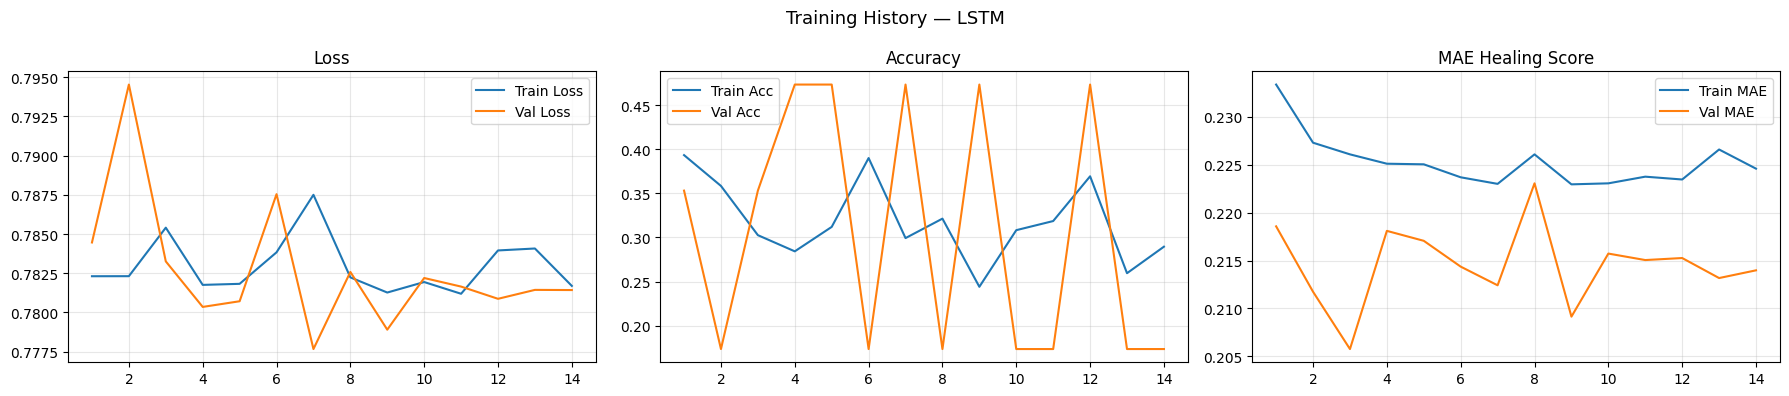

In [17]:

_opt_lstm = tf.keras.optimizers.Adam(learning_rate=0.001)
trainer_LSTM = customTrainingLoop(
    model        = model_LSTM(),
    model_name   = 'LSTM',
    optimizer    = _opt_lstm,
    loss_fn      = MultiOutputLoss(emotion_weight=0.7, healing_weight=0.3),
    log_dir      = LOG_DIR,
    class_weight = class_weight,
    callbacks    = [
        CustomEarlyStopping(patience=7, min_delta=0.001),
        OverfittingDetector(threshold=0.15),
        TrainingSummaryLogger(),
        CustomLearningRateScheduler(optimizer=_opt_lstm, initial_lr=0.001, factor=0.5, patience=3, min_lr=1e-6),
        CustomModelCheckpoint(
            filepath=os.path.join(OUTPUT_DIR, 'LSTM_checkpoint.keras'),
            monitor='val_loss'
        ),
    ],
)
trainer_LSTM.fit(train_ds, val_ds, epochs=EPOCH)
trainer_LSTM.plot_history()


════════════════════════════════════════════════════════════
  Model     : GRU
  Epochs    : 50
  Optimizer : Adam
  Loss      : MultiOutputLoss
  LR        : 0.001000
  Callbacks : ['CustomEarlyStopping', 'OverfittingDetector', 'TrainingSummaryLogger', 'CustomLearningRateScheduler', 'CustomModelCheckpoint']
════════════════════════════════════════════════════════════


[SummaryLogger] Training dimulai — ? batch/epoch

Epoch 001/50 (9.7s) — loss: 0.7832  acc: 0.3257  mae: 0.2341  val_loss: 0.7744  val_acc: 0.4734  val_mae: 0.2154
✓ Best model saved (val_loss=0.7744)

[Checkpoint] Simpan model → ./results\GRU_checkpoint.keras (val_loss=0.7744)
Epoch 002/50 (6.8s) — loss: 0.7850  acc: 0.3493  mae: 0.2275  val_loss: 0.7912  val_acc: 0.1734  val_mae: 0.2256
Epoch 003/50 (6.6s) — loss: 0.7825  acc: 0.2958  mae: 0.2240  val_loss: 0.7773  val_acc: 0.4734  val_mae: 0.2198
Epoch 004/50 (6.5s) — loss: 0.7819  acc: 0.3575  mae: 0.2267  val_loss: 0.7788  val_acc: 0.3531  val_mae: 0.2146

[LRSched

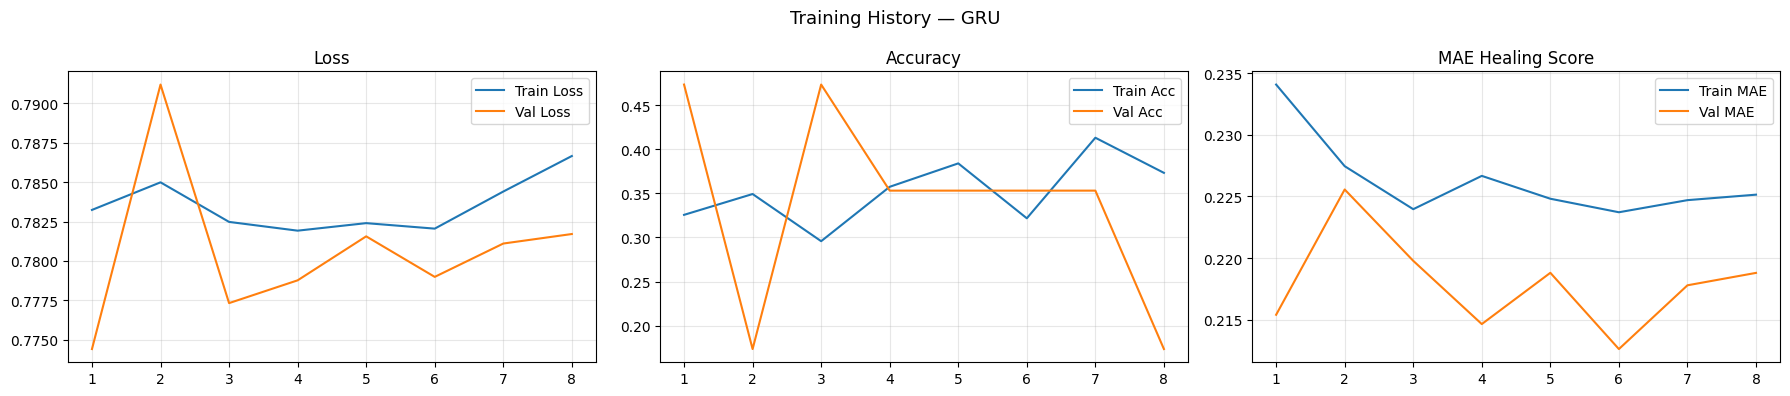

In [18]:
_opt_gru = tf.keras.optimizers.Adam(learning_rate=0.001)
trainer_GRU = customTrainingLoop(
    model        = model_GRU(),
    model_name   = 'GRU',
    optimizer    = _opt_gru,
    loss_fn      = MultiOutputLoss(emotion_weight=0.7, healing_weight=0.3),
    log_dir      = LOG_DIR,
    class_weight = class_weight,
    callbacks    = [
        CustomEarlyStopping(patience=7, min_delta=0.001),
        OverfittingDetector(threshold=0.15),
        TrainingSummaryLogger(),
        CustomLearningRateScheduler(optimizer=_opt_gru, initial_lr=0.001, factor=0.5, patience=3, min_lr=1e-6),
        CustomModelCheckpoint(filepath=os.path.join(OUTPUT_DIR, 'GRU_checkpoint.keras'), monitor='val_loss'),
    ],
)
trainer_GRU.fit(train_ds, val_ds, epochs=EPOCH)
trainer_GRU.plot_history()


════════════════════════════════════════════════════════════
  Model     : CNN
  Epochs    : 50
  Optimizer : Adam
  Loss      : MultiOutputLoss
  LR        : 0.001000
  Callbacks : ['CustomEarlyStopping', 'OverfittingDetector', 'TrainingSummaryLogger', 'CustomLearningRateScheduler', 'CustomModelCheckpoint']
════════════════════════════════════════════════════════════


[SummaryLogger] Training dimulai — ? batch/epoch

Epoch 001/50 (3.3s) — loss: 1.1694  acc: 0.5320  mae: 1.0338  val_loss: 0.7390  val_acc: 0.6062  val_mae: 0.2087
✓ Best model saved (val_loss=0.7390)

[Checkpoint] Simpan model → ./results\CNN_checkpoint.keras (val_loss=0.7390)
Epoch 002/50 (1.5s) — loss: 0.5154  acc: 0.7786  mae: 0.3187  val_loss: 0.6591  val_acc: 0.7969  val_mae: 0.2199
✓ Best model saved (val_loss=0.6591)

[Checkpoint] Simpan model → ./results\CNN_checkpoint.keras (val_loss=0.6591)
Epoch 003/50 (1.5s) — loss: 0.3958  acc: 0.8932  mae: 0.2095  val_loss: 0.5341  val_acc: 0.8781  val_mae: 0.2009
✓ Best 

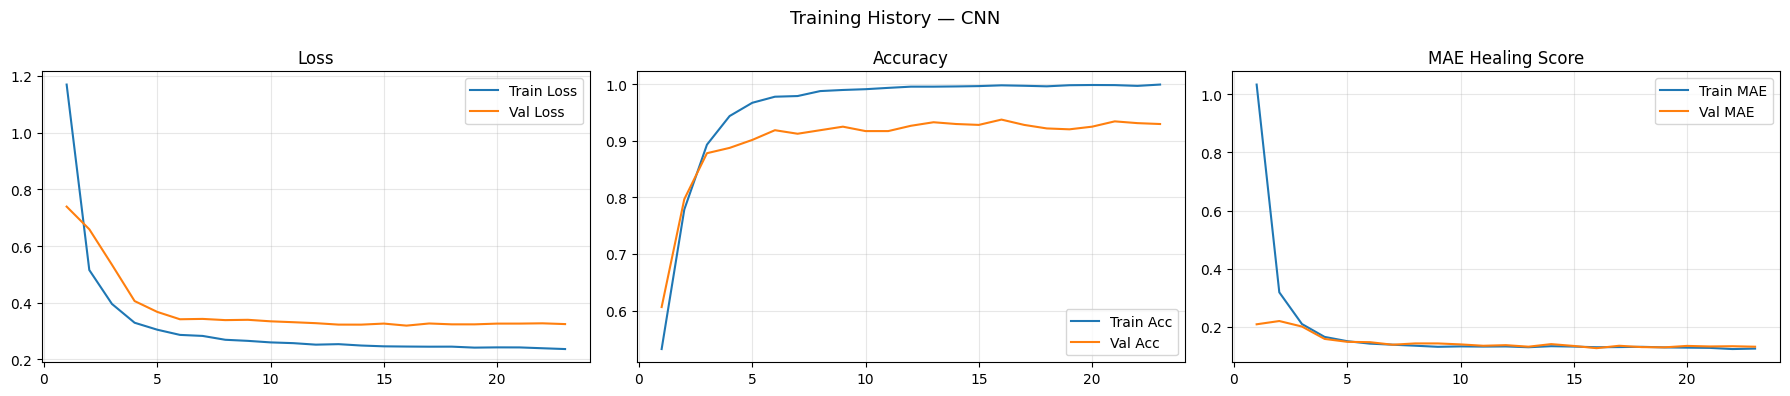

In [19]:
_opt_cnn = tf.keras.optimizers.Adam(learning_rate=0.001)
trainer_CNN = customTrainingLoop(
    model        = model_CNN(),
    model_name   = 'CNN',
    optimizer    = _opt_cnn,
    loss_fn      = MultiOutputLoss(emotion_weight=0.7, healing_weight=0.3),
    log_dir      = LOG_DIR,
    class_weight = class_weight,
    callbacks    = [
        CustomEarlyStopping(patience=7, min_delta=0.001),
        OverfittingDetector(threshold=0.15),
        TrainingSummaryLogger(),
        CustomLearningRateScheduler(optimizer=_opt_cnn, initial_lr=0.001, factor=0.5, patience=3, min_lr=1e-6),
        CustomModelCheckpoint(filepath=os.path.join(OUTPUT_DIR, 'CNN_checkpoint.keras'), monitor='val_loss'),
    ],
)
trainer_CNN.fit(train_ds, val_ds, epochs=EPOCH)
trainer_CNN.plot_history()


════════════════════════════════════════════════════════════
  Model     : BiLSTM
  Epochs    : 50
  Optimizer : Adam
  Loss      : MultiOutputLoss
  LR        : 0.001000
  Callbacks : ['CustomEarlyStopping', 'StopAtAccuracy', 'OverfittingDetector', 'TrainingSummaryLogger', 'CustomLearningRateScheduler', 'CustomModelCheckpoint']
════════════════════════════════════════════════════════════


[SummaryLogger] Training dimulai — ? batch/epoch

Epoch 001/50 (17.7s) — loss: 0.5436  acc: 0.7179  mae: 0.2360  val_loss: 0.3912  val_acc: 0.8656  val_mae: 0.1354
✓ Best model saved (val_loss=0.3912)

[Checkpoint] Simpan model → ./results\BiLSTM_checkpoint.keras (val_loss=0.3912)
Epoch 002/50 (12.2s) — loss: 0.2947  acc: 0.9510  mae: 0.1783  val_loss: 0.3623  val_acc: 0.8859  val_mae: 0.1303
✓ Best model saved (val_loss=0.3623)

[Checkpoint] Simpan model → ./results\BiLSTM_checkpoint.keras (val_loss=0.3623)
Epoch 003/50 (12.0s) — loss: 0.2589  acc: 0.9713  mae: 0.1480  val_loss: 0.3613  val_acc: 0

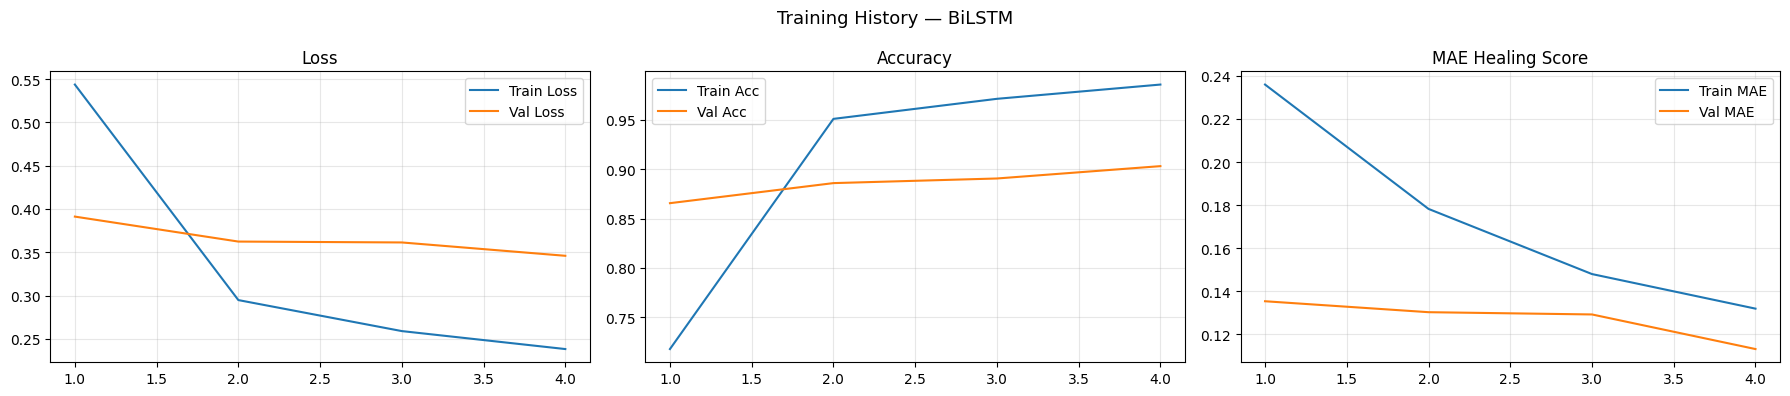

In [20]:
_opt_bilstm = tf.keras.optimizers.Adam(learning_rate=0.001)
trainer_BiLSTM = customTrainingLoop(
    model        = model_BiLSTM(),
    model_name   = 'BiLSTM',
    optimizer    = _opt_bilstm,
    loss_fn      = MultiOutputLoss(emotion_weight=0.7, healing_weight=0.3),
    log_dir      = LOG_DIR,
    class_weight = class_weight,
    callbacks    = [
        CustomEarlyStopping(patience=7, min_delta=0.001),
        StopAtAccuracy(target_acc=0.90),
        OverfittingDetector(threshold=0.15),
        TrainingSummaryLogger(),
        CustomLearningRateScheduler(optimizer=_opt_bilstm, initial_lr=0.001, factor=0.5, patience=3, min_lr=1e-6),
        CustomModelCheckpoint(filepath=os.path.join(OUTPUT_DIR, 'BiLSTM_checkpoint.keras'), monitor='val_loss'),
    ],
)
trainer_BiLSTM.fit(train_ds, val_ds, epochs=EPOCH)
trainer_BiLSTM.plot_history()


════════════════════════════════════════════════════════════
  Model     : BiGRU
  Epochs    : 50
  Optimizer : Adam
  Loss      : MultiOutputLoss
  LR        : 0.001000
  Callbacks : ['CustomEarlyStopping', 'StopAtAccuracy', 'OverfittingDetector', 'TrainingSummaryLogger', 'CustomLearningRateScheduler', 'CustomModelCheckpoint']
════════════════════════════════════════════════════════════


[SummaryLogger] Training dimulai — ? batch/epoch

Epoch 001/50 (15.7s) — loss: 0.5369  acc: 0.7499  mae: 0.2380  val_loss: 0.3804  val_acc: 0.8687  val_mae: 0.1387
✓ Best model saved (val_loss=0.3804)

[Checkpoint] Simpan model → ./results\BiGRU_checkpoint.keras (val_loss=0.3804)
Epoch 002/50 (10.5s) — loss: 0.3070  acc: 0.9457  mae: 0.1814  val_loss: 0.3308  val_acc: 0.9078  val_mae: 0.1171
✓ Best model saved (val_loss=0.3308)

[StopAtAccuracy] Val accuracy 0.9078 ≥ target 0.90 di epoch 2 → stop.

[Checkpoint] Simpan model → ./results\BiGRU_checkpoint.keras (val_loss=0.3308)
 Training dihentikan ol

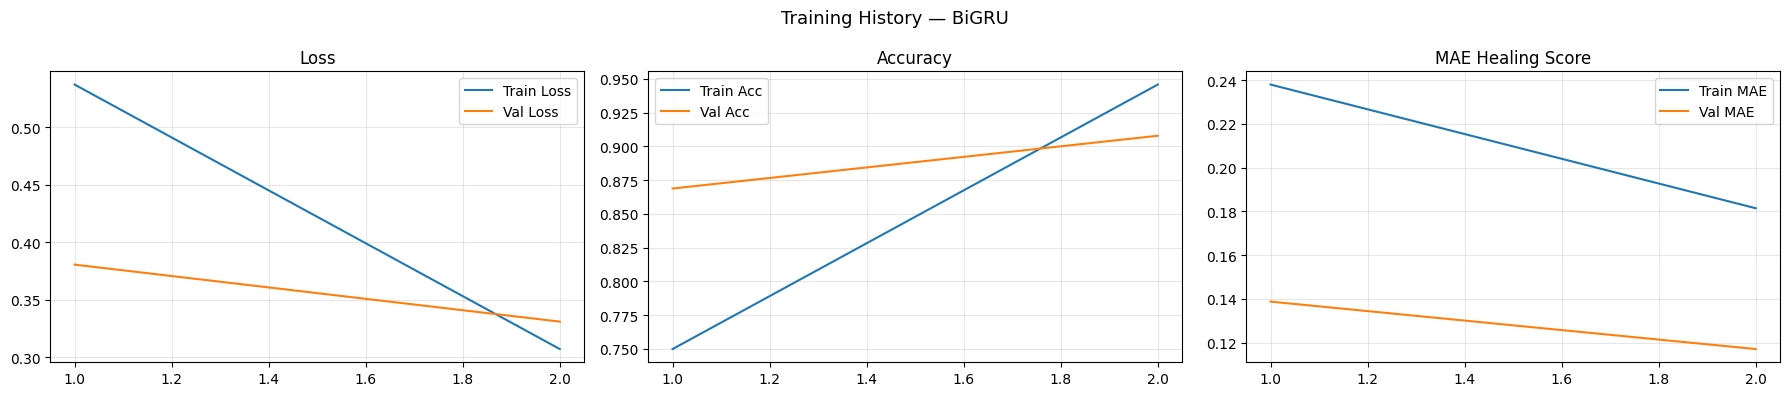

In [21]:
_opt_bigru = tf.keras.optimizers.Adam(learning_rate=0.001)
trainer_BiGRU = customTrainingLoop(
    model        = model_BiGRU(),
    model_name   = 'BiGRU',
    optimizer    = _opt_bigru,
    loss_fn      = MultiOutputLoss(emotion_weight=0.7, healing_weight=0.3),
    log_dir      = LOG_DIR,
    class_weight = class_weight,
    callbacks    = [
        CustomEarlyStopping(patience=7, min_delta=0.001),
        StopAtAccuracy(target_acc=0.90),
        OverfittingDetector(threshold=0.15),
        TrainingSummaryLogger(),
        CustomLearningRateScheduler(optimizer=_opt_bigru, initial_lr=0.001, factor=0.5, patience=3, min_lr=1e-6),
        CustomModelCheckpoint(filepath=os.path.join(OUTPUT_DIR, 'BiGRU_checkpoint.keras'), monitor='val_loss'),
    ],
)
trainer_BiGRU.fit(train_ds, val_ds, epochs=EPOCH)
trainer_BiGRU.plot_history()

### Transfer learning

In [22]:
BERT_MODEL_NAME = 'bert-base-uncased'
BERT_MAX_LENGTH = 128

bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

def bert_encode(texts, tokenizer, max_length):
    encoded = tokenizer(
        list(texts),
        max_length     = max_length,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'tf'
    )
    return (
        encoded['input_ids'],
        encoded['attention_mask'],
        encoded['token_type_ids']
    )

print("Encoding train...")
train_ids, train_mask, train_type = bert_encode(X_train, bert_tokenizer, BERT_MAX_LENGTH)

print("Encoding val...")
val_ids, val_mask, val_type = bert_encode(X_val, bert_tokenizer, BERT_MAX_LENGTH)

print("Encoding test...")
test_ids, test_mask, test_type = bert_encode(X_test, bert_tokenizer, BERT_MAX_LENGTH)

bert_train_ds = (
    tf.data.Dataset
    .from_tensor_slices((
        {
            'input_ids'     : train_ids,
            'attention_mask': train_mask,
            'token_type_ids': train_type,
        },
        (y_train, yh_train)
    ))
    .shuffle(len(y_train), seed=RANDOM_SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

bert_val_ds = (
    tf.data.Dataset
    .from_tensor_slices((
        {
            'input_ids'     : val_ids,
            'attention_mask': val_mask,
            'token_type_ids': val_type,
        },
        (y_val, yh_val)
    ))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

bert_test_ds = (
    tf.data.Dataset
    .from_tensor_slices((
        {
            'input_ids'     : test_ids,
            'attention_mask': test_mask,
            'token_type_ids': test_type,
        },
        (y_test, yh_test)
    ))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("✓ bert_train_ds :", len(list(bert_train_ds)), "batch")
print("✓ bert_val_ds   :", len(list(bert_val_ds)),   "batch")
print("✓ bert_test_ds  :", len(list(bert_test_ds)),  "batch")

Encoding train...
Encoding val...
Encoding test...
✓ bert_train_ds : 161 batch
✓ bert_val_ds   : 20 batch
✓ bert_test_ds  : 21 batch


In [23]:
def model_BERT():
    input_ids      = tf.keras.Input(shape=(BERT_MAX_LENGTH,), dtype=tf.int32, name='input_ids')
    attention_mask = tf.keras.Input(shape=(BERT_MAX_LENGTH,), dtype=tf.int32, name='attention_mask')
    token_type_ids = tf.keras.Input(shape=(BERT_MAX_LENGTH,), dtype=tf.int32, name='token_type_ids')

    bert_layer = TFBertModel.from_pretrained(BERT_MODEL_NAME, from_pt=False)
    bert_layer.trainable = False  
    bert_outputs = bert_layer(
        {
            'input_ids'      : input_ids,
            'attention_mask' : attention_mask,
            'token_type_ids' : token_type_ids,
        }
    )

    cls_output = bert_outputs.last_hidden_state[:, 0, :] 

    shared = Dense(256, activation='relu', name='shared_dense')(cls_output)
    shared = Dropout(0.3,                  name='shared_dropout')(shared)

    out_emotion = Dense(NUM_CLASSES, activation='softmax', name='emotion_output')(shared)
    out_healing = Dense(1,           activation='linear',  name='healing_output')(shared)

    return tf.keras.Model(
        inputs  = [input_ids, attention_mask, token_type_ids],
        outputs = (out_emotion, out_healing),
        name    = 'BERT'
    )

In [24]:
class CustomTrainerBERT:
    def __init__(
        self,
        model,
        model_name,
        optimizer,
        loss_fn,
        log_dir      = None,
        class_weight = None,
        callbacks    = None,
    ):
        self.model        = model
        self.model_name   = model_name
        self.optimizer    = optimizer
        self.loss_fn      = loss_fn
        self.log_dir      = log_dir or LOG_DIR
        self.class_weight = class_weight
        self.callbacks    = callbacks or []
        self._emotion_loss_fn = CustomLossFunction(smoothing=0.1)

        self.history = {
            'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': [],
            'mae': [], 'val_mae': [],
        }

        self.best_val_loss   = np.inf
        self.checkpoint_path = os.path.join(OUTPUT_DIR, f'{model_name}_best.keras')

        self.train_writer = tf.summary.create_file_writer(
            os.path.join(self.log_dir, self.model_name, 'train')
        )
        self.val_writer = tf.summary.create_file_writer(
            os.path.join(self.log_dir, self.model_name, 'val')
        )

        self.train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
        self.train_acc_metric  = tf.keras.metrics.SparseCategoricalAccuracy(name='train_acc')
        self.train_mae_metric  = tf.keras.metrics.MeanAbsoluteError(name='train_mae')
        self.val_loss_metric   = tf.keras.metrics.Mean(name='val_loss')
        self.val_acc_metric    = tf.keras.metrics.SparseCategoricalAccuracy(name='val_acc')
        self.val_mae_metric    = tf.keras.metrics.MeanAbsoluteError(name='val_mae')

        self._huber = tf.keras.losses.Huber(delta=0.5)
        if class_weight is not None:
            self._cw_tensor = tf.constant(list(class_weight.values()), dtype=tf.float32)
        else:
            self._cw_tensor = None


    @tf.function
    def _train_step(self, X_batch, y_emotion, y_healing):
        if self._cw_tensor is not None:
            sample_weights = tf.gather(self._cw_tensor, tf.cast(y_emotion, tf.int32))
        else:
            sample_weights = tf.ones_like(tf.cast(y_emotion, tf.float32))

        with tf.GradientTape() as tape:
            pred_emotion, pred_healing = self.model(X_batch, training=True)

            num_classes   = tf.shape(pred_emotion)[-1]
            num_classes_f = tf.cast(num_classes, tf.float32)
            y_onehot      = tf.one_hot(tf.cast(y_emotion, tf.int32), depth=num_classes)
            smooth_labels = y_onehot * (1.0 - 0.1) + (0.1 / num_classes_f)
            pred_clipped  = tf.clip_by_value(pred_emotion, 1e-7, 1.0)
            ce_loss       = -tf.reduce_sum(smooth_labels * tf.math.log(pred_clipped), axis=-1)
            emotion_loss  = tf.reduce_mean(ce_loss * sample_weights)

            healing_loss = self._huber(tf.expand_dims(y_healing, -1), pred_healing)

            loss = 0.7 * emotion_loss + 0.3 * healing_loss

        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        self.train_loss_metric.update_state(loss)
        self.train_acc_metric.update_state(y_emotion, pred_emotion)
        self.train_mae_metric.update_state(tf.expand_dims(y_healing, -1), pred_healing)

    @tf.function
    def _val_step(self, X_batch, y_emotion, y_healing):
        pred_emotion, pred_healing = self.model(X_batch, training=False)

        emotion_loss = self._emotion_loss_fn(y_emotion, pred_emotion)
        healing_loss = self._huber(tf.expand_dims(y_healing, -1), pred_healing)

        loss = 0.7 * emotion_loss + 0.3 * healing_loss

        self.val_loss_metric.update_state(loss)
        self.val_acc_metric.update_state(y_emotion, pred_emotion)
        self.val_mae_metric.update_state(tf.expand_dims(y_healing, -1), pred_healing)


    def fit(self, train_ds, val_ds, epochs):
        print(f"\n{'═'*60}")
        print(f"  Model     : {self.model_name}")
        print(f"  Epochs    : {epochs}")
        print(f"  Optimizer : {self.optimizer.__class__.__name__}")
        print(f"  Loss      : {self.loss_fn.__class__.__name__}")
        print(f"  LR        : {float(self.optimizer.learning_rate):.6f}")
        print(f"  Callbacks : {[c.__class__.__name__ for c in self.callbacks]}")
        print(f"{'═'*60}\n")
        
        self.model.stop_training = False
        for cb in self.callbacks:
            cb.model = self.model
        for cb in self.callbacks:
            if hasattr(cb, 'on_train_begin'):
                cb.on_train_begin(logs={})

        self.total_start = time.time()
        t_loss = 0

        for epoch in range(epochs):
            epoch_start = time.time()

            for X_batch, (y_emotion, y_healing) in train_ds:
                self._train_step(X_batch, y_emotion, y_healing)

            for X_batch, (y_emotion, y_healing) in val_ds:
                self._val_step(X_batch, y_emotion, y_healing)

            t_loss  = self.train_loss_metric.result().numpy()
            t_acc   = self.train_acc_metric.result().numpy()
            t_mae   = self.train_mae_metric.result().numpy()
            v_loss  = self.val_loss_metric.result().numpy()
            v_acc   = self.val_acc_metric.result().numpy()
            v_mae   = self.val_mae_metric.result().numpy()
            elapsed = time.time() - epoch_start

            self.history['loss'].append(t_loss)
            self.history['accuracy'].append(t_acc)
            self.history['mae'].append(t_mae)
            self.history['val_loss'].append(v_loss)
            self.history['val_accuracy'].append(v_acc)
            self.history['val_mae'].append(v_mae)

            with self.train_writer.as_default():
                tf.summary.scalar('loss',     t_loss, step=epoch)
                tf.summary.scalar('accuracy', t_acc,  step=epoch)
                tf.summary.scalar('mae',      t_mae,  step=epoch)

            with self.val_writer.as_default():
                tf.summary.scalar('loss',     v_loss, step=epoch)
                tf.summary.scalar('accuracy', v_acc,  step=epoch)
                tf.summary.scalar('mae',      v_mae,  step=epoch)

            print(f"Epoch {epoch+1:03d}/{epochs} ({elapsed:.1f}s) — "
                  f"loss: {t_loss:.4f}  acc: {t_acc:.4f}  mae: {t_mae:.4f}  "
                  f"val_loss: {v_loss:.4f}  val_acc: {v_acc:.4f}  val_mae: {v_mae:.4f}")

            gap = v_loss - t_loss
            if gap > 0.15:
                print(f" Overfitting — gap: {gap:.4f}")

            if v_loss < self.best_val_loss:
                self.best_val_loss = v_loss
                self.model.save(self.checkpoint_path)
                print(f"✓ Best model saved (val_loss={v_loss:.4f})")

            self.train_loss_metric.reset_states()
            self.train_acc_metric.reset_states()
            self.train_mae_metric.reset_states()
            self.val_loss_metric.reset_states()
            self.val_acc_metric.reset_states()
            self.val_mae_metric.reset_states()

            logs = {
                'loss': t_loss, 'accuracy': t_acc, 'mae': t_mae,
                'val_loss': v_loss, 'val_accuracy': v_acc, 'val_mae': v_mae,
            }
            for cb in self.callbacks:
                if hasattr(cb, 'on_epoch_end'):
                    cb.on_epoch_end(epoch, logs=logs)

            if getattr(self.model, 'stop_training', False):
                print(f" Training dihentikan oleh callback di epoch {epoch+1}")
                break

        total_elapsed = time.time() - self.total_start

        for cb in self.callbacks:
            if hasattr(cb, 'on_train_end'):
                cb.on_train_end(logs={'loss': t_loss})

        print(f"\n{'═'*60}")
        print(f"  Selesai       : {self.model_name}")
        print(f"  Total waktu   : {total_elapsed:.1f} detik")
        print(f"  Best val_loss : {self.best_val_loss:.4f}")
        print(f"  Checkpoint    : {self.checkpoint_path}")
        print(f"{'═'*60}\n")


    def evaluate(self, test_ds, y_test, yh_test, le):
        print(f"\n{'─'*60}")
        print(f"  Evaluasi : {self.model_name}")
        print(f"{'─'*60}")

        y_pred_emotion_list = []
        y_pred_healing_list = []

        for X_batch, _ in test_ds:
            pred_e, pred_h = self.model(X_batch, training=False)
            y_pred_emotion_list.append(pred_e.numpy())
            y_pred_healing_list.append(pred_h.numpy())

        y_pred_emotion_probs = np.concatenate(y_pred_emotion_list, axis=0)
        y_pred_healing       = np.concatenate(y_pred_healing_list, axis=0).flatten()
        y_pred_emotion       = np.argmax(y_pred_emotion_probs, axis=1)

        acc      = accuracy_score(y_test, y_pred_emotion)
        f1_macro = f1_score(y_test, y_pred_emotion, average='macro')
        f1_w     = f1_score(y_test, y_pred_emotion, average='weighted')
        mae      = np.mean(np.abs(yh_test - y_pred_healing))

        print(f"  Accuracy   : {acc:.4f}  {'✓' if acc >= 0.85 else '✗'} target > 0.85")
        print(f"  F1 Macro   : {f1_macro:.4f}")
        print(f"  F1 Weighted: {f1_w:.4f}")
        print(f"  MAE Healing: {mae:.4f}  {'✓ < 0.2' if mae < 0.2 else '✗ > 0.2'}")
        print(f"\n{classification_report(y_test, y_pred_emotion, target_names=le.classes_)}")

        cm = confusion_matrix(y_test, y_pred_emotion)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=le.classes_, yticklabels=le.classes_)
        plt.title(f'Confusion Matrix — {self.model_name}')
        plt.ylabel('True'); plt.xlabel('Predicted')
        plt.tight_layout(); plt.show()

        return {
            'accuracy':    acc,
            'f1_macro':    f1_macro,
            'f1_weighted': f1_w,
            'mae_healing': mae,
        }


    def plot_history(self):
        epochs = range(1, len(self.history['loss']) + 1)

        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        fig.suptitle(f'Training History — {self.model_name}', fontsize=13)

        axes[0].plot(epochs, self.history['loss'],     label='Train Loss')
        axes[0].plot(epochs, self.history['val_loss'], label='Val Loss')
        axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

        axes[1].plot(epochs, self.history['accuracy'],     label='Train Acc')
        axes[1].plot(epochs, self.history['val_accuracy'], label='Val Acc')
        axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

        axes[2].plot(epochs, self.history['mae'],     label='Train MAE')
        axes[2].plot(epochs, self.history['val_mae'], label='Val MAE')
        axes[2].set_title('MAE Healing Score'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

        plt.tight_layout(); plt.show()


In [25]:
_opt_bert = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)

trainer_BERT = CustomTrainerBERT(
    model        = model_BERT(),
    model_name   = 'BERT',
    optimizer    = _opt_bert,
    loss_fn      = MultiOutputLoss(emotion_weight=0.7, healing_weight=0.3),
    log_dir      = LOG_DIR,
    class_weight = class_weight,
    callbacks    = [
        CustomEarlyStopping(patience=5, min_delta=0.001),  
        OverfittingDetector(threshold=0.15),
        TrainingSummaryLogger(),
        CustomLearningRateScheduler(          
            optimizer  = _opt_bert,
            initial_lr = 3e-4,
            factor     = 0.5,
            patience   = 3,
            min_lr     = 1e-6
        ),
        CustomModelCheckpoint(
            filepath = os.path.join(OUTPUT_DIR, 'BERT_checkpoint.keras'),
            monitor  = 'val_loss'
        ),
    ],
)
trainer_BERT.fit(bert_train_ds, bert_val_ds, epochs=EPOCH)  

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w



════════════════════════════════════════════════════════════
  Model     : BERT
  Epochs    : 50
  Optimizer : Adam
  Loss      : MultiOutputLoss
  LR        : 0.000300
  Callbacks : ['CustomEarlyStopping', 'OverfittingDetector', 'TrainingSummaryLogger', 'CustomLearningRateScheduler', 'CustomModelCheckpoint']
════════════════════════════════════════════════════════════


[SummaryLogger] Training dimulai — ? batch/epoch

Epoch 001/50 (166.7s) — loss: 0.7466  acc: 0.5037  mae: 0.3760  val_loss: 0.6371  val_acc: 0.6375  val_mae: 0.2345
✓ Best model saved (val_loss=0.6371)

[Checkpoint] Simpan model → ./results\BERT_checkpoint.keras (val_loss=0.6371)
Epoch 002/50 (153.5s) — loss: 0.6738  acc: 0.5896  mae: 0.2895  val_loss: 0.6238  val_acc: 0.6219  val_mae: 0.2142
✓ Best model saved (val_loss=0.6238)

[Checkpoint] Simpan model → ./results\BERT_checkpoint.keras (val_loss=0.6238)
Epoch 003/50 (154.8s) — loss: 0.6467  acc: 0.6259  mae: 0.2638  val_loss: 0.5816  val_acc: 0.6797  val_mae: 0.20

## Evaluasi dan Perbandingan


────────────────────────────────────────────────────────────
  Evaluasi : LSTM
────────────────────────────────────────────────────────────
  Accuracy   : 0.4727  ✗ target > 0.85
  F1 Macro   : 0.2140
  F1 Weighted: 0.3034
  MAE Healing: 0.2213  ✗ > 0.2

              precision    recall  f1-score   support

  acceptance       0.00      0.00      0.00       112
       anger       0.47      1.00      0.64       303
     anxiety       0.00      0.00      0.00       226

    accuracy                           0.47       641
   macro avg       0.16      0.33      0.21       641
weighted avg       0.22      0.47      0.30       641



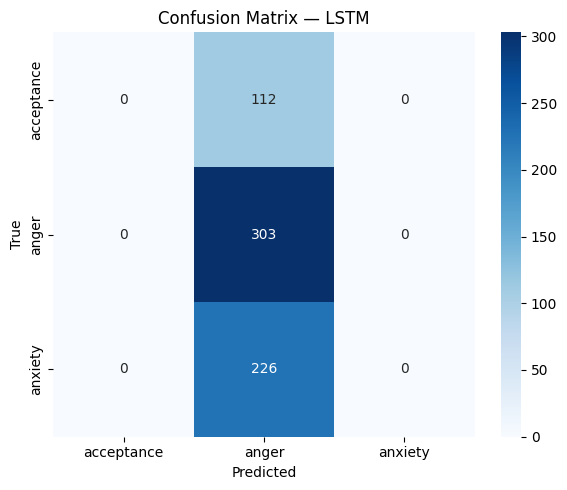


────────────────────────────────────────────────────────────
  Evaluasi : GRU
────────────────────────────────────────────────────────────
  Accuracy   : 0.4727  ✗ target > 0.85
  F1 Macro   : 0.2140
  F1 Weighted: 0.3034
  MAE Healing: 0.2239  ✗ > 0.2

              precision    recall  f1-score   support

  acceptance       0.00      0.00      0.00       112
       anger       0.47      1.00      0.64       303
     anxiety       0.00      0.00      0.00       226

    accuracy                           0.47       641
   macro avg       0.16      0.33      0.21       641
weighted avg       0.22      0.47      0.30       641



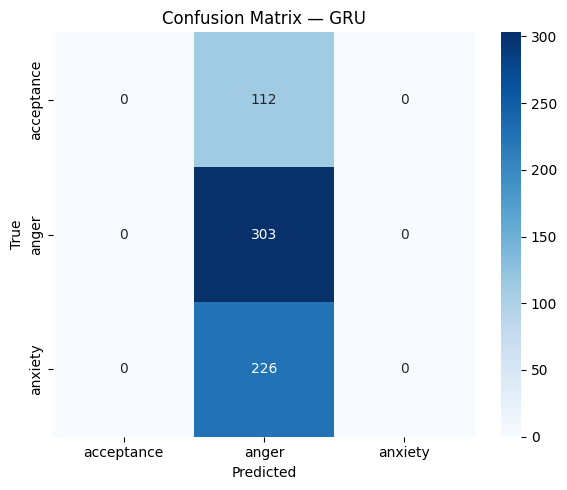


────────────────────────────────────────────────────────────
  Evaluasi : CNN
────────────────────────────────────────────────────────────
  Accuracy   : 0.9314  ✓ target > 0.85
  F1 Macro   : 0.9191
  F1 Weighted: 0.9315
  MAE Healing: 0.1263  ✓ < 0.2

              precision    recall  f1-score   support

  acceptance       0.86      0.89      0.88       112
       anger       0.96      0.96      0.96       303
     anxiety       0.93      0.91      0.92       226

    accuracy                           0.93       641
   macro avg       0.92      0.92      0.92       641
weighted avg       0.93      0.93      0.93       641



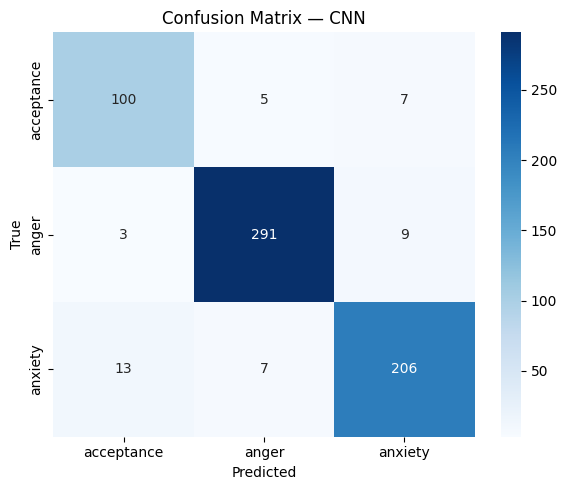


────────────────────────────────────────────────────────────
  Evaluasi : BiLSTM
────────────────────────────────────────────────────────────
  Accuracy   : 0.9376  ✓ target > 0.85
  F1 Macro   : 0.9255
  F1 Weighted: 0.9376
  MAE Healing: 0.1103  ✓ < 0.2

              precision    recall  f1-score   support

  acceptance       0.90      0.87      0.88       112
       anger       0.97      0.95      0.96       303
     anxiety       0.91      0.96      0.93       226

    accuracy                           0.94       641
   macro avg       0.93      0.92      0.93       641
weighted avg       0.94      0.94      0.94       641



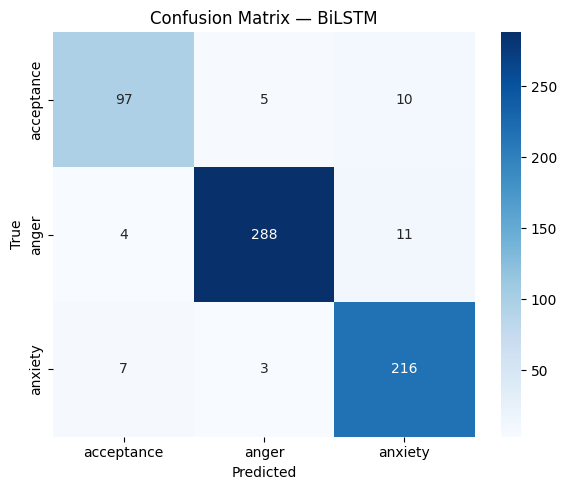


────────────────────────────────────────────────────────────
  Evaluasi : BiGRU
────────────────────────────────────────────────────────────
  Accuracy   : 0.9345  ✓ target > 0.85
  F1 Macro   : 0.9236
  F1 Weighted: 0.9351
  MAE Healing: 0.1157  ✓ < 0.2

              precision    recall  f1-score   support

  acceptance       0.84      0.93      0.88       112
       anger       0.97      0.94      0.96       303
     anxiety       0.94      0.92      0.93       226

    accuracy                           0.93       641
   macro avg       0.92      0.93      0.92       641
weighted avg       0.94      0.93      0.94       641



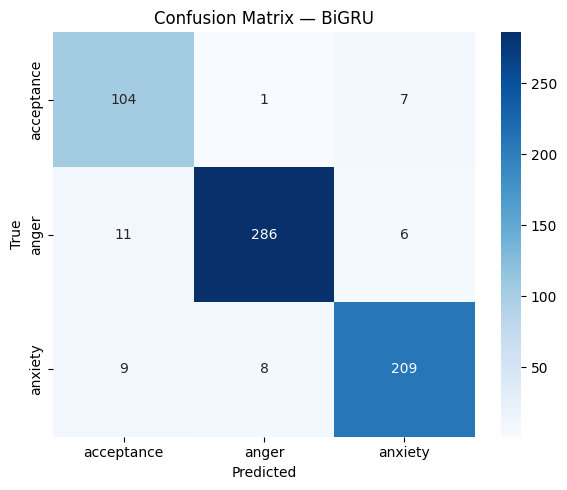


────────────────────────────────────────────────────────────
  Evaluasi : BERT
────────────────────────────────────────────────────────────
  Accuracy   : 0.7051  ✗ target > 0.85
  F1 Macro   : 0.6727
  F1 Weighted: 0.7096
  MAE Healing: 0.1871  ✓ < 0.2

              precision    recall  f1-score   support

  acceptance       0.51      0.59      0.55       112
       anger       0.84      0.75      0.79       303
     anxiety       0.66      0.70      0.68       226

    accuracy                           0.71       641
   macro avg       0.67      0.68      0.67       641
weighted avg       0.72      0.71      0.71       641



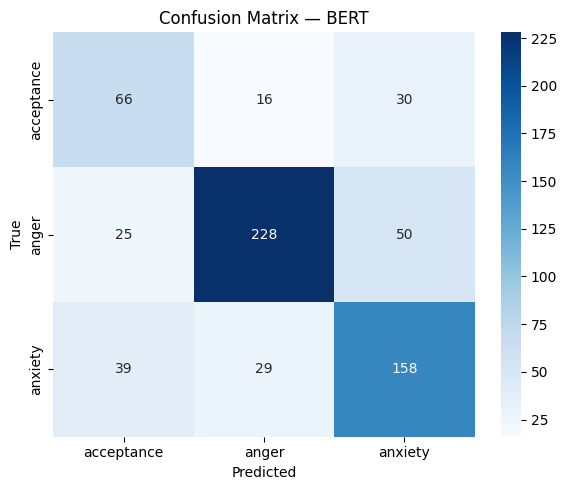


═══════════════════════════════════════════════════════
   Perbandingan Semua Model
═══════════════════════════════════════════════════════
        accuracy  f1_macro  f1_weighted  mae_healing
BiLSTM    0.9376    0.9255       0.9376       0.1103
BiGRU     0.9345    0.9236       0.9351       0.1157
CNN       0.9314    0.9191       0.9315       0.1263
BERT      0.7051    0.6727       0.7096       0.1871
LSTM      0.4727    0.2140       0.3034       0.2213
GRU       0.4727    0.2140       0.3034       0.2239
═══════════════════════════════════════════════════════

✓ Model terbaik : BiLSTM
  F1 Macro      : 0.9255
  Accuracy      : 0.9376  ✓ > 0.85
  MAE Healing   : 0.1103  ✓ < 0.2


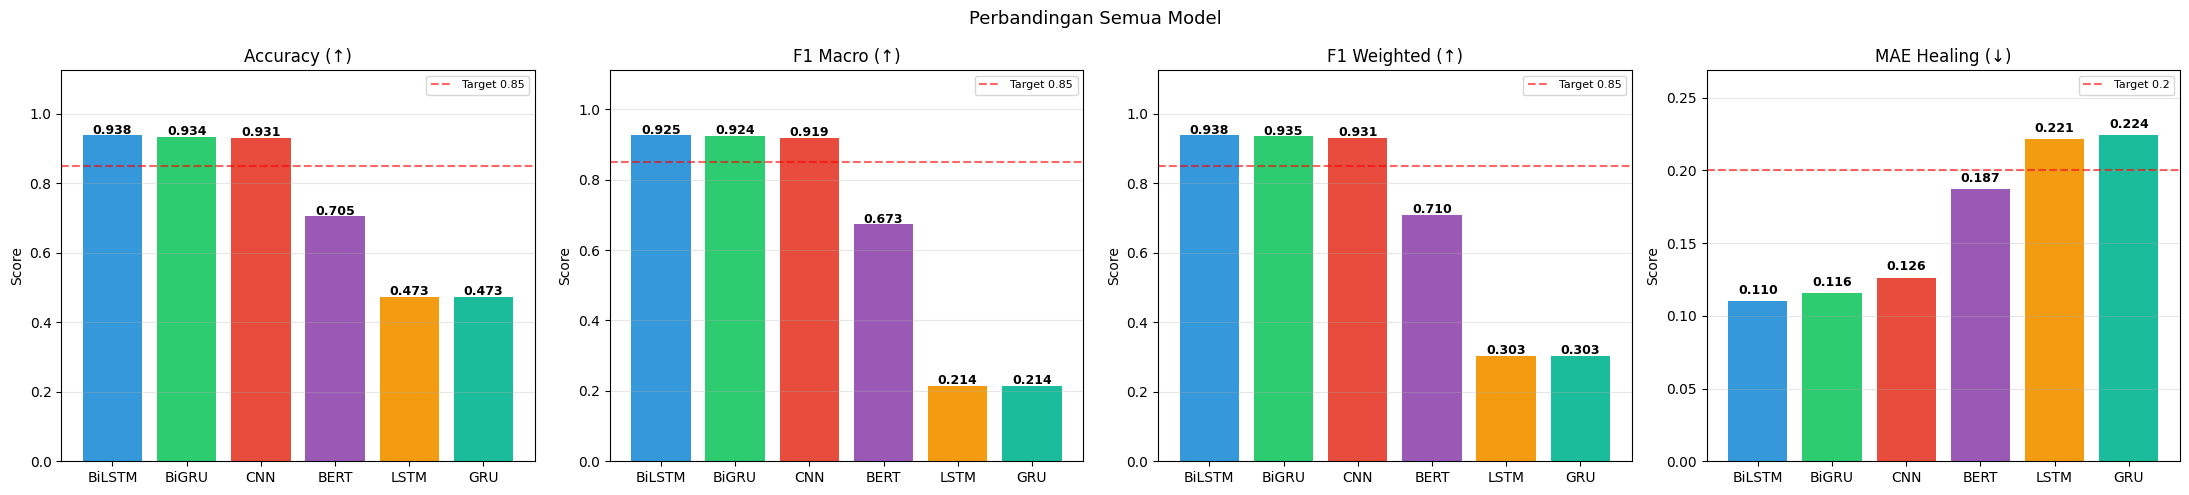

In [26]:
all_trainers = {
    'LSTM'  : trainer_LSTM,
    'GRU'   : trainer_GRU,
    'CNN'   : trainer_CNN,
    'BiLSTM': trainer_BiLSTM,
    'BiGRU' : trainer_BiGRU,
}

eval_results = {}
for name, trainer in all_trainers.items():
    eval_results[name] = trainer.evaluate(test_ds, y_test, yh_test, le)

eval_results['BERT'] = trainer_BERT.evaluate(bert_test_ds, y_test, yh_test, le)

eval_df        = pd.DataFrame(eval_results).T.round(4)
eval_df_sorted = eval_df.sort_values('f1_macro', ascending=False)

best_model_name = eval_df_sorted.index[0]

print("\n═══════════════════════════════════════════════════════")
print("   Perbandingan Semua Model")
print("═══════════════════════════════════════════════════════")
print(eval_df_sorted.to_string())
print("═══════════════════════════════════════════════════════")
print(f"\n✓ Model terbaik : {best_model_name}")
print(f"  F1 Macro      : {eval_df_sorted['f1_macro'].iloc[0]:.4f}")
print(f"  Accuracy      : {eval_df_sorted['accuracy'].iloc[0]:.4f}  "
      f"{'✓ > 0.85' if eval_df_sorted['accuracy'].iloc[0] >= 0.85 else '✗ < 0.85'}")
print(f"  MAE Healing   : {eval_df_sorted['mae_healing'].iloc[0]:.4f}  "
      f"{'✓ < 0.2' if eval_df_sorted['mae_healing'].iloc[0] < 0.2 else '✗ > 0.2'}")

# Plot perbandingan 4 metrik
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Perbandingan Semua Model', fontsize=13)

metrics_plot = ['accuracy', 'f1_macro', 'f1_weighted', 'mae_healing']
titles_plot  = ['Accuracy (↑)', 'F1 Macro (↑)', 'F1 Weighted (↑)', 'MAE Healing (↓)']
colors       = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c']
targets      = [0.85, 0.85, 0.85, 0.2]

for ax, metric, title, target in zip(axes, metrics_plot, titles_plot, targets):
    vals = eval_df_sorted[metric]
    bars = ax.bar(eval_df_sorted.index, vals, color=colors[:len(eval_df_sorted)])
    ax.set_title(title)
    ax.set_ylabel('Score')
    ax.set_ylim(0, max(vals.max() * 1.2, 0.1))
    ax.axhline(y=target, color='red', linestyle='--', alpha=0.6, label=f'Target {target}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Simpan Model

In [27]:
print("=" * 60)
print("  MENYIMPAN SEMUA MODEL")
print("=" * 60)

all_trainers_full = {**all_trainers, 'BERT': trainer_BERT}

print("\n[1] Simpan semua model → .keras")
for name, trainer in all_trainers_full.items():
    path = os.path.join(OUTPUT_DIR, f'{name}_final.keras')
    trainer.model.save(path)
    print(f"  ✓ {name:8s} → {path}")

print(f"\n[2] Simpan model terbaik ({best_model_name}) → best_model.keras")
best_trainer    = all_trainers_full[best_model_name]
best_keras_path = os.path.join(OUTPUT_DIR, 'best_model.keras')
best_trainer.model.save(best_keras_path)
print(f"  ✓ {best_keras_path}")

print("\n[3] Ekspor semua model → SavedModel format")
for name, trainer in all_trainers_full.items():
    sm_path = os.path.join(ALL_MODELS_DIR, name)
    trainer.model.export(sm_path)
    print(f"  ✓ {name:8s} → {sm_path}")

print(f"\n[4] Ekspor model terbaik ({best_model_name}) → SavedModel/best")
best_sm_path = os.path.join(BEST_MODEL_DIR, 'best_model')
best_trainer.model.export(best_sm_path)
print(f"  ✓ {best_sm_path}")

eval_export = {
    name: {k: float(v) for k, v in m.items()}
    for name, m in eval_results.items()
}
eval_export['_meta'] = {
    'best_model'      : best_model_name,
    'best_f1_macro'   : float(eval_df_sorted['f1_macro'].iloc[0]),
    'best_accuracy'   : float(eval_df_sorted['accuracy'].iloc[0]),
    'best_mae_healing': float(eval_df_sorted['mae_healing'].iloc[0]),
}
json_path = os.path.join(ARTIFACTS_DIR, 'eval_results.json')
with open(json_path, 'w') as f:
    json.dump(eval_export, f, indent=2)

print(f"\n{'═'*60}")
print(f"  ✓ Model terbaik    : {best_model_name}")
print(f"  ✓ Accuracy         : {eval_df_sorted['accuracy'].iloc[0]:.4f}")
print(f"  ✓ F1 Macro         : {eval_df_sorted['f1_macro'].iloc[0]:.4f}")
print(f"  ✓ MAE Healing      : {eval_df_sorted['mae_healing'].iloc[0]:.4f}")
print(f"  ✓ .keras path      : {best_keras_path}")
print(f"  ✓ SavedModel best  : {best_sm_path}")
print(f"  ✓ Eval JSON        : {json_path}")
print(f"{'═'*60}")

  MENYIMPAN SEMUA MODEL

[1] Simpan semua model → .keras
  ✓ LSTM     → ./results\LSTM_final.keras
  ✓ GRU      → ./results\GRU_final.keras
  ✓ CNN      → ./results\CNN_final.keras
  ✓ BiLSTM   → ./results\BiLSTM_final.keras
  ✓ BiGRU    → ./results\BiGRU_final.keras
  ✓ BERT     → ./results\BERT_final.keras

[2] Simpan model terbaik (BiLSTM) → best_model.keras
  ✓ ./results\best_model.keras

[3] Ekspor semua model → SavedModel format
INFO:tensorflow:Assets written to: ./results/all_models\LSTM\assets


INFO:tensorflow:Assets written to: ./results/all_models\LSTM\assets


Saved artifact at './results/all_models\LSTM'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200), dtype=tf.int32, name='input')
Output Type:
  Tuple[TensorSpec(shape=(None, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  2235086443280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235083086864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235086442896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235086443472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235086445200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235086445392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235086444240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235086445584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235086446160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235200335184: TensorSpec(shape=(), dtype=tf.

INFO:tensorflow:Assets written to: ./results/all_models\GRU\assets


Saved artifact at './results/all_models\GRU'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200), dtype=tf.int32, name='input')
Output Type:
  Tuple[TensorSpec(shape=(None, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  2235083090704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235083091088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235376720720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235376720912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235376721488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235376722064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235376721872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235376722448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235376722256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235376723216: TensorSpec(shape=(), dtype=tf.r

...

Saved artifact at './results/all_models\BiGRU'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200), dtype=tf.int32, name='input')
Output Type:
  Tuple[TensorSpec(shape=(None, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  2235376719760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235503339728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235503340688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235503340304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235503337616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235503341072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235503340880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235503341648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235503342224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2235503342032: TensorSpec(shape=(), dtype=tf

INFO:tensorflow:Assets written to: ./results/all_models\BERT\assets


Saved artifact at './results/all_models\BERT'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 128), dtype=tf.int32, name='input_ids'), TensorSpec(shape=(None, 128), dtype=tf.int32, name='attention_mask'), TensorSpec(shape=(None, 128), dtype=tf.int32, name='token_type_ids')]
Output Type:
  Tuple[TensorSpec(shape=(None, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  2236336230032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2236336230992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2236336229648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2236336228304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2236336230224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2236336230608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2236336230800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2236336229456: TensorSpec(shape

INFO:tensorflow:Assets written to: ./results/best_model\best_model\assets


Saved artifact at './results/best_model\best_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200), dtype=tf.int32, name='input')
Output Type:
  Tuple[TensorSpec(shape=(None, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  2235376719568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2233583905168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2233583906128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2233583906320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2233583904400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2233583906704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2233583905744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2233583907280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2233583907856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2233583905936: TensorSpec(shape=(), dty

## Inference

In [28]:
import sys
import os
import importlib.util


notebook_dir = os.getcwd()
while not os.path.exists(os.path.join(notebook_dir, 'DS')):
    parent = os.path.dirname(notebook_dir)
    if parent == notebook_dir: 
        raise FileNotFoundError("Folder 'DS' tidak ditemukan. Pastikan notebook berada di workspace yang benar.")
    notebook_dir = parent

# Path ke preprocessing file
prep_path = os.path.join(notebook_dir, 'DS', 'Emotion Label', 'preprocessing_noprob.py')

# Load dengan importlib
spec = importlib.util.spec_from_file_location("preprocessing", prep_path)
prep = importlib.util.module_from_spec(spec)
spec.loader.exec_module(prep)

print(f"✓ Preprocessing module loaded dari: {prep_path}")


def predict_non_bert(text, model, tokenizer, le, max_length=MAX_LENGTH):
    text = prep.clean_text(text)
    seq    = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

    pred_e, pred_h = model.predict(padded, verbose=0)
    probs          = pred_e[0]
    idx            = np.argmax(probs)

    return {
        'text'         : text,
        'prediksi'     : le.classes_[idx],
        'confidence'   : float(probs[idx]),
        'semua'        : {le.classes_[i]: float(p) for i, p in enumerate(probs)},
        'healing_score': float(pred_h[0][0]),
    }


def predict_bert(text, model, bert_tokenizer, le, max_length=BERT_MAX_LENGTH):
    text = prep.clean_text(text)
    encoded = bert_tokenizer(
        text,
        max_length     = max_length,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'tf'
    )
    inputs = {
        'input_ids'     : encoded['input_ids'],
        'attention_mask': encoded['attention_mask'],
        'token_type_ids': encoded['token_type_ids'],
    }
    pred_e, pred_h = model.predict(inputs, verbose=0)
    probs          = pred_e[0]
    idx            = np.argmax(probs)

    return {
        'text'         : text,
        'prediksi'     : le.classes_[idx],
        'confidence'   : float(probs[idx]),
        'semua'        : {le.classes_[i]: float(p) for i, p in enumerate(probs)},
        'healing_score': float(pred_h[0][0]),
    }


def predict_all(text, all_trainers, trainer_bert, tokenizer, bert_tokenizer, le):

    print(f"\n{'═'*65}")
    print(f"  [ALL MODE]")
    print(f"  Input : \"{text}\"")
    print(f"{'═'*65}")

    results = {}

    for name, trainer in all_trainers.items():
        res           = predict_non_bert(text, trainer.model, tokenizer, le)
        results[name] = res
        print(f"\n  [{name}]")
        print(f"    Emosi         : {res['prediksi']} ({res['confidence']:.2%})")
        print(f"    Healing Score : {res['healing_score']:.4f}")
        print(f"    Distribusi    : { {k: f'{v:.2%}' for k, v in res['semua'].items()} }")

    res_bert        = predict_bert(text, trainer_bert.model, bert_tokenizer, le)
    results['BERT'] = res_bert
    print(f"\n  [BERT]")
    print(f"    Emosi         : {res_bert['prediksi']} ({res_bert['confidence']:.2%})")
    print(f"    Healing Score : {res_bert['healing_score']:.4f}")
    print(f"    Distribusi    : { {k: f'{v:.2%}' for k, v in res_bert['semua'].items()} }")

    # Voting majority emosi
    votes       = [r['prediksi'] for r in results.values()]
    majority    = max(set(votes), key=votes.count)
    vote_counts = {label: votes.count(label) for label in le.classes_}

    # Rata-rata healing score semua model
    avg_healing = float(np.mean([r['healing_score'] for r in results.values()]))

    print(f"\n{'─'*65}")
    print(f"  Voting Emosi   : {vote_counts}")
    print(f"  Emosi Final    : {majority} ({votes.count(majority)}/{len(votes)} model sepakat)")
    print(f"  Healing Score  : {avg_healing:.4f} (rata-rata semua model)")
    print(f"{'═'*65}\n")

    return results, majority, avg_healing


def predict_best(text, best_model_name, all_trainers, trainer_bert,
                 tokenizer, bert_tokenizer, le):
    print(f"\n{'═'*65}")
    print(f"  [BEST MODE — {best_model_name}]")
    print(f"  Input : \"{text}\"")
    print(f"{'═'*65}")

    if best_model_name == 'BERT':
        res = predict_bert(text, trainer_bert.model, bert_tokenizer, le)
    else:
        res = predict_non_bert(text, all_trainers[best_model_name].model, tokenizer, le)

    print(f"\n  Emosi         : {res['prediksi']} ({res['confidence']:.2%})")
    print(f"  Healing Score : {res['healing_score']:.4f}")
    print(f"  Distribusi    : { {k: f'{v:.2%}' for k, v in res['semua'].items()} }")
    print(f"{'═'*65}\n")

    return res


# RUN INFERENCE

test_sentences = [
    "I feel so sad and hopeless, nothing seems to go right",
    "Today was absolutely amazing, I am so happy!",
    "I am furious about what just happened, this is unacceptable",
    "I don't know what to feel anymore, everything is numb",
]

# ── ALL MODE ────────────────────────────────────────────────
print("=" * 65)
print("  INFERENCE — ALL MODE (semua 6 model)")
print("=" * 65)

for sentence in test_sentences:
    predict_all(
        text           = sentence,
        all_trainers   = all_trainers,
        trainer_bert   = trainer_BERT,
        tokenizer      = tokenizer,
        bert_tokenizer = bert_tokenizer,
        le             = le
    )

# ── BEST MODE ───────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"  INFERENCE — BEST MODE (model terbaik: {best_model_name})")
print("=" * 65)

for sentence in test_sentences:
    predict_best(
        text            = sentence,
        best_model_name = best_model_name,
        all_trainers    = all_trainers,
        trainer_bert    = trainer_BERT,
        tokenizer       = tokenizer,
        bert_tokenizer  = bert_tokenizer,
        le              = le
    )

✓ Preprocessing module loaded dari: d:\Farizky\casptoneAfterCrash\healmate_ai\DS\Emotion Label\preprocessing_noprob.py
  INFERENCE — ALL MODE (semua 6 model)

═════════════════════════════════════════════════════════════════
  [ALL MODE]
  Input : "I feel so sad and hopeless, nothing seems to go right"
═════════════════════════════════════════════════════════════════

  [LSTM]
    Emosi         : anger (34.23%)
    Healing Score : -0.1417
    Distribusi    : {'acceptance': '32.86%', 'anger': '34.23%', 'anxiety': '32.90%'}

  [GRU]
    Emosi         : anger (35.28%)
    Healing Score : -0.1337
    Distribusi    : {'acceptance': '32.44%', 'anger': '35.28%', 'anxiety': '32.28%'}

  [CNN]
    Emosi         : anxiety (88.80%)
    Healing Score : -0.2091
    Distribusi    : {'acceptance': '5.73%', 'anger': '5.47%', 'anxiety': '88.80%'}

  [BiLSTM]
    Emosi         : anxiety (93.64%)
    Healing Score : -0.2216
    Distribusi    : {'acceptance': '3.15%', 'anger': '3.21%', 'anxiety': '93.64%'


  [BiGRU]
    Emosi         : anxiety (95.28%)
    Healing Score : -0.1991
    Distribusi    : {'acceptance': '2.43%', 'anger': '2.29%', 'anxiety': '95.28%'}



  [BERT]
    Emosi         : anxiety (95.10%)
    Healing Score : -0.3093
    Distribusi    : {'acceptance': '2.14%', 'anger': '2.76%', 'anxiety': '95.10%'}

─────────────────────────────────────────────────────────────────
  Voting Emosi   : {'acceptance': 0, 'anger': 2, 'anxiety': 4}
  Emosi Final    : anxiety (4/6 model sepakat)
  Healing Score  : -0.2024 (rata-rata semua model)
═════════════════════════════════════════════════════════════════


═════════════════════════════════════════════════════════════════
  [ALL MODE]
  Input : "Today was absolutely amazing, I am so happy!"
═════════════════════════════════════════════════════════════════

  [LSTM]
    Emosi         : anger (34.23%)
    Healing Score : -0.1417
    Distribusi    : {'acceptance': '32.86%', 'anger': '34.23%', 'anxiety': '32.90%'}

  [GRU]
    Emosi         : anger (35.28%)
    Healing Score : -0.1337
    Distribusi    : {'acceptance': '32.44%', 'anger': '35.28%', 'anxiety': '32.28%'}

  [CNN]
    Emosi         : 